# Table of Contents

0. [Modeling](#0)
   * [Exploratory Data Analysis](#eda)
   * [Model Training and Testing](#model)
1. [Foundations of the Alignment Problem](#1)
   * [Alignment Gap & Impossibility Theorem](#alignment-gap--impossibility-theorem)
   * [Group-Conditional Error Rates (FPR & FNR)](#group-conditional-error-rates)
2. [Explainability and Interpretability](#2)
   * [Interpretable-by-Design Models (GLMs & GAMs)](#interpretable-by-design-models)
   * [Post-Hoc Explanations (LIME & SHAP)](#post-hoc-explanations)
   * [Counterfactuals & Recourse (DiCE)](#counterfactuals--recourse)
3. [Algorithmic Bias Measurement](#3)
   * [Disparity Metrics (AIR, ME, SMD)](#disparity-metrics-air-me-smd)
   * [Intersectional Subgroup Testing](#intersectional-subgroup-testing)
4. [Robustness, Generalization, and Dataset Drift](#4)
   * [Distribution Shift (PSI, KS, MMD)](#distribution-shift-psi-ks-mmd)
   * [Stress Testing & Sensitivity Analysis](#stress-testing--sensitivity-analysis)
5. [ML Security and Abuse Pathways](#5)
   * [Data Poisoning Simulations](#data-poisoning-simulations)
   * [Evasion & Privacy Attacks](#evasion--privacy-attacks)
6. [Capstone Integration: 2024 HMDA Mortgage Classification](#6)
   * [End-to-End Sociotechnical Audit](#end-to-end-sociotechnical-audit)
   * [Optimization Objectives & Failure Modes](#optimization-objectives--failure-modes)
   * [Mitigations & Deployment Recommendations](#mitigations--deployment-recommendations)

## Group 2 : Capstone Project 2024 Home Mortgage Disclosure Act (HMDA)

#### Group Members
* Gift Natchapa
* Hazel Mugadza
* Shreyas Kuradagi
* Steven Chu
* Tatenda Kagande
* Oliastic Ngoshi

# 0. Modeling<a id="0"></a>

## Exploratory Data Analysis<a id="eda"></a>

In [1]:
# Check if duckdb is already installed
try:
    import duckdb
    print("Libraries already installed. Skipping installation.")
except ImportError:
    print("Libraries not found. Installing from requirements.txt...")
    # Execute the install command
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])

Libraries already installed. Skipping installation.


In [ ]:
import sys
import subprocess
import pandas as pd
import duckdb
import os
import urllib.request
import zipfile

In [3]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

In [4]:
zip_path = "data/2024_lar.zip"
extracted_path = "data/2024_lar.txt"
url = "https://files.ffiec.cfpb.gov/dynamic-data/2024/2024_lar.zip"

os.makedirs("data", exist_ok=True)

# Download
if not os.path.exists(zip_path):
    print("Downloading dataset... (this may take a few minutes)")
    urllib.request.urlretrieve(url, zip_path)
    print("Download complete.")
else:
    print("Dataset already exists locally. Skipping download.")

# Extract
if not os.path.exists(extracted_path):
    print("Extracting...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall("data/")
    print("Extraction complete.")
else:
    print("Already extracted. Skipping.")

Dataset already exists locally. Skipping download.
Already extracted. Skipping.


In [5]:
! head "data/2024_lar.txt" | csvlook

| activity_year | lei                  | derived_msa_md | state_code | county_code |   census_tract | conforming_loan_limit | derived_loan_product_type | derived_dwelling_category            | derived_ethnicity       | derived_race       | derived_sex | action_taken | purchaser_type | preapproval | loan_type | loan_purpose | lien_status | reverse_mortgage | open_end_line_of_credit | business_or_commercial_purpose | loan_amount | combined_loan_to_value_ratio | interest_rate | rate_spread | hoepa_status | total_loan_costs | total_points_and_fees | origination_charges | discount_points | lender_credits | loan_term | prepayment_penalty_term | intro_rate_period | negative_amortization | interest_only_payment | balloon_payment | other_nonamortizing_features | property_value | construction_method | occupancy_type | manufactured_home_secured_property_type | manufactured_home_land_property_interest | total_units | multifamily_affordable_units | income | debt_to_income_ratio | applicant_credit_s

In [6]:
con = duckdb.connect()
con.execute("DESCRIBE SELECT * FROM read_csv('data/2024_lar.txt', sep='|', header=true)").df()

,column_name,column_type,null,key,default,extra
0,activity_year,BIGINT,YES,None,None,None
1,lei,VARCHAR,YES,None,None,None
2,derived_msa_md,BIGINT,YES,None,None,None
3,state_code,VARCHAR,YES,None,None,None
4,county_code,VARCHAR,YES,None,None,None
...,...,...,...,...,...,...
94,ffiec_msa_md_median_family_income,BIGINT,YES,None,None,None
95,tract_to_msa_income_percentage,DOUBLE,YES,None,None,None
96,tract_owner_occupied_units,BIGINT,YES,None,None,None
97,tract_one_to_four_family_homes,BIGINT,YES,None,None,None


In [7]:
data = con.execute("""
    SELECT
        action_taken,
        loan_amount,
        loan_type,
        loan_purpose,
        income,
        debt_to_income_ratio,
        applicant_credit_score_type,
        derived_race,
        derived_sex,
        ffiec_msa_md_median_family_income
    FROM read_csv('data/2024_lar.txt', sep='|', header=true, ignore_errors=true)
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [8]:
data.head().T

,0,1,2,3,4
action_taken,1,1,1,1,1
loan_amount,655000,295000,275000,545000,365000
loan_type,1,1,1,1,1
loan_purpose,31,1,31,1,31
income,300,85,85,276,90
debt_to_income_ratio,39,37,49,30%-<36%,43
applicant_credit_score_type,1,2,3,9,2
derived_race,White,White,White,White,White
derived_sex,Male,Joint,Female,Joint,Male
ffiec_msa_md_median_family_income,101900,109700,101300,116900,123700


In [9]:
data.shape

(10478709, 10)

In [10]:
# Gender vs Race cross-tabulation (matches xtabs in R)
gender_race_xtab = pd.crosstab(data['derived_sex'], data['derived_race'])
gender_race_xtab

derived_race,2 or more minority races,American Indian or Alaska Native,Asian,Black or African American,Free Form Text Only,Joint,Native Hawaiian or Other Pacific Islander,Race Not Available,White
derived_sex,,,,,,,,,
Female,9737,26143,149048,398652,665,7119,7097,250412,1566309
Joint,4756,11997,213346,188213,790,213526,6074,320953,2644965
Male,12111,41303,300066,355967,1510,7996,12275,417479,2468572
Sex Not Available,658,798,4519,6872,36,993,281,795745,31726


In [11]:
data['debt_to_income_ratio'].value_counts()

debt_to_income_ratio
NA          2382305
30%-<36%    1090698
20%-<30%    1062818
50%-60%      823097
>60%         618876
<20%         451238
49           398579
44           330190
42           313330
43           282382
41           275994
48           267287
40           265272
39           255395
47           250884
45           250212
46           243559
38           238129
Exempt       236407
37           226653
36           215404
Name: count, dtype: int64

In [12]:
# Demographic Breakdown (Race)
race_counts = data['derived_race'].value_counts(normalize=True) * 100
print("\nRace Percentages:")
print(race_counts.round(2))


Race Percentages:
derived_race
White                                        64.05
Race Not Available                           17.03
Black or African American                     9.06
Asian                                         6.37
Joint                                         2.19
American Indian or Alaska Native              0.77
2 or more minority races                      0.26
Native Hawaiian or Other Pacific Islander     0.25
Free Form Text Only                           0.03
Name: proportion, dtype: float64


In [13]:
# 1. Get counts for all unique values
counts = data['derived_sex'].value_counts()
total = counts.sum()

# 2. Loop through every sex type found in the data
for label, count in counts.items():
    percentage = (count / total) * 100
    print(f"{label}: {percentage:.2f}%")

Male: 34.52%
Joint: 34.40%
Female: 23.05%
Sex Not Available: 8.03%


In [14]:
# 1. First, create an independent copy of your slice 
# This breaks the link to the original 12M row file
data = data.copy() 

# 2. Now perform your mapping safely
# 1: Originated, 2: Approved but not accepted -> Approved (1)
# 3: Application denied -> Denied (0)
data['target'] = data['action_taken'].map({1: 1, 2: 1, 3: 0})

In [15]:
import numpy as np
# 1. First, filter out zero/negative income to prevent division by zero (Infinity)
# It is best to do this BEFORE creating ratios
data['income'] = pd.to_numeric(data['income'], errors='coerce')

# 2. Numeric transformations
# Use 'income' for the ratio as originally intended
data['loan_to_income_ratio'] = data['loan_amount'] / data['income']
#data['log_loan_amount'] = np.log1p(data['loan_amount'])

# Note: Dividing by (median / 1000) is standard for HMDA 'relative income' metrics
data['relative_income'] = data['income'] / (data['ffiec_msa_md_median_family_income'] / 1000)

# 3. Apply the DTI mapping
dti_map = {'<20%': 15, '20%-<30%': 25, '30%-<36%': 33, '50%-60%': 55}

# Map the strings, then fill remaining values by attempting to convert them to numbers
data['dti_numeric'] = data['debt_to_income_ratio'].map(dti_map).fillna(
    pd.to_numeric(data['debt_to_income_ratio'], errors='coerce')
)

# 4. Final Clean up
# Replace any unexpected 'inf' with NaN and drop them
data = data.replace([np.inf, -np.inf], np.nan)

In [16]:
data.head().T

,0,1,2,3,4
action_taken,1,1,1,1,1
loan_amount,655000,295000,275000,545000,365000
loan_type,1,1,1,1,1
loan_purpose,31,1,31,1,31
income,300,85,85,276,90
debt_to_income_ratio,39,37,49,30%-<36%,43
applicant_credit_score_type,1,2,3,9,2
derived_race,White,White,White,White,White
derived_sex,Male,Joint,Female,Joint,Male
ffiec_msa_md_median_family_income,101900,109700,101300,116900,123700


In [17]:
data["dti_numeric"] = data["dti_numeric"].astype("object")

mask = data["debt_to_income_ratio"].str.lower() == "exempt"
data.loc[mask, "dti_numeric"] = "exempt"

In [18]:
data.head().T

,0,1,2,3,4
action_taken,1,1,1,1,1
loan_amount,655000,295000,275000,545000,365000
loan_type,1,1,1,1,1
loan_purpose,31,1,31,1,31
income,300,85,85,276,90
debt_to_income_ratio,39,37,49,30%-<36%,43
applicant_credit_score_type,1,2,3,9,2
derived_race,White,White,White,White,White
derived_sex,Male,Joint,Female,Joint,Male
ffiec_msa_md_median_family_income,101900,109700,101300,116900,123700


In [19]:
def dti_risk(num):
    if num == "exempt":
        return "exempt"
    if num < 36:
        return "low_risk"
    if 36 <= num <= 43:
        return "mid_risk"
    if 44 <= num <= 50:
        return "high_risk"
    if num > 50:
        return "extreme_risk"

data['dti_category'] = data['dti_numeric'].apply(dti_risk)

In [20]:
# Drop the original categorical columns that have been transformed
cols_to_drop = ['loan_amount', 'income', 'action_taken','debt_to_income_ratio','loan_to_income_ratio','dti_numeric']
data = data.drop(columns=cols_to_drop)

In [21]:
data.sample(8).T

,2569920,3325222,5857187,6669513,9461153,2183113,8678661,1357714
loan_type,1,1,1,1,1,2,1,1
loan_purpose,1,2,32,1,1,1,1,31
applicant_credit_score_type,2,8,3,2,12,9,9,3
derived_race,Black or African American,Race Not Available,White,White,Race Not Available,White,White,Asian
derived_sex,Female,Sex Not Available,Female,Joint,Female,Joint,Joint,Female
ffiec_msa_md_median_family_income,100900,109800,110000,105400,103300,103500,82000,158700
target,1.0,0.0,1.0,1.0,0.0,NaN,NaN,1.0
relative_income,0.951437,0.327869,1.081818,0.910816,1.239109,1.603865,0.902439,1.795841
dti_category,high_risk,None,mid_risk,high_risk,None,None,None,low_risk


In [22]:
# Create a mapping dictionary for formal terminology
race_map = {
    'Black or African American': 'African-American',
    'White': 'Caucasian',
    'Asian': 'Asian',
    'American Indian or Alaska Native': 'Indigenous',
    'Native Hawaiian or Other Pacific Islander': 'Pacific Islander',
    '2 or more minority races': 'Multiracial',
    'Joint': 'Joint',
    'Free Form Text Only': 'Other'
}

# Apply the mapping and group "Race Not Available" as NaN to drop or impute
data['race'] = data['derived_race'].map(race_map)

# Drop the original string race column
data = data.drop(columns=['derived_race'])

# Optional: Group smaller categories into 'Other' if they are under a 1% threshold
# to improve model stability
minority_groups = ['Indigenous', 'Pacific Islander', 'Multiracial', 'Other']
data['race'] = data['race'].replace(minority_groups, 'Minority')

In [23]:
data.head().T

,0,1,2,3,4
loan_type,1,1,1,1,1
loan_purpose,31,1,31,1,31
applicant_credit_score_type,1,2,3,9,2
derived_sex,Male,Joint,Female,Joint,Male
ffiec_msa_md_median_family_income,101900,109700,101300,116900,123700
target,1.0,1.0,1.0,1.0,1.0
relative_income,2.944063,0.77484,0.839092,2.360992,0.727567
dti_category,mid_risk,mid_risk,high_risk,low_risk,mid_risk
race,Caucasian,Caucasian,Caucasian,Caucasian,Caucasian


In [24]:
data.isnull().sum()

loan_type                                  0
loan_purpose                               0
applicant_credit_score_type                0
derived_sex                                0
ffiec_msa_md_median_family_income          0
target                               2362464
relative_income                       260776
dti_category                         3001181
race                                 1784589
dtype: int64

In [25]:
# Drop all rows containing any null values
data = data.dropna()
data.isnull().sum()

loan_type                            0
loan_purpose                         0
applicant_credit_score_type          0
derived_sex                          0
ffiec_msa_md_median_family_income    0
target                               0
relative_income                      0
dti_category                         0
race                                 0
dtype: int64

In [26]:
data.shape

(6174185, 9)

In [27]:
# Gender vs Race cross-tabulation (matches xtabs in R)
gender_race_xtab = pd.crosstab(data['derived_sex'], data['race'])
gender_race_xtab

race,African-American,Asian,Caucasian,Joint,Minority
derived_sex,,,,,
Female,252712,98595,1089908,5064,27042
Joint,128306,149304,2007916,156341,15893
Male,226728,199408,1741574,5767,42486
Sex Not Available,3468,2722,19240,661,1050


In [28]:
# 1. Get counts for all unique values
counts = data['race'].value_counts()
total = counts.sum()

# 2. Loop through every sex type found in the data
for label, count in counts.items():
    percentage = (count / total) * 100
    print(f"{label}: {percentage:.2f}%")

Caucasian: 78.69%
African-American: 9.90%
Asian: 7.29%
Joint: 2.72%
Minority: 1.40%


In [29]:
# 1. Remove rows where 'Sex Not Available' is recorded
data = data[data['derived_sex'] != 'Sex Not Available'].copy()
# 2. Rename the column to 'gender'
data = data.rename(columns={'derived_sex': 'gender'})

In [30]:
# Gender vs Race cross-tabulation (matches xtabs in R)
gender_race_xtab = pd.crosstab(data['gender'], data['race'])
gender_race_xtab

race,African-American,Asian,Caucasian,Joint,Minority
gender,,,,,
Female,252712,98595,1089908,5064,27042
Joint,128306,149304,2007916,156341,15893
Male,226728,199408,1741574,5767,42486


In [31]:
data.shape

(6147044, 9)

In [32]:
data.head().T

,0,1,2,3,4
loan_type,1,1,1,1,1
loan_purpose,31,1,31,1,31
applicant_credit_score_type,1,2,3,9,2
gender,Male,Joint,Female,Joint,Male
ffiec_msa_md_median_family_income,101900,109700,101300,116900,123700
target,1.0,1.0,1.0,1.0,1.0
relative_income,2.944063,0.77484,0.839092,2.360992,0.727567
dti_category,mid_risk,mid_risk,high_risk,low_risk,mid_risk
race,Caucasian,Caucasian,Caucasian,Caucasian,Caucasian


In [33]:
column_list = data.columns.tolist()
print(column_list)

['loan_type', 'loan_purpose', 'applicant_credit_score_type', 'gender', 'ffiec_msa_md_median_family_income', 'target', 'relative_income', 'dti_category', 'race']


In [34]:
# 1. Check the specific unique values
print("Unique values in target:", data['target'].unique())
# 2. Check the count and distribution of each class
print("\nClass Distribution:")
print(data['target'].value_counts())
# 3. Check the percentage distribution
print("\nPercentage Distribution:")
print(data['target'].value_counts(normalize=True) * 100)

Unique values in target: [1. 0.]

Class Distribution:
target
1.0    5085279
0.0    1061765
Name: count, dtype: int64

Percentage Distribution:
target
1.0    82.727226
0.0    17.272774
Name: proportion, dtype: float64


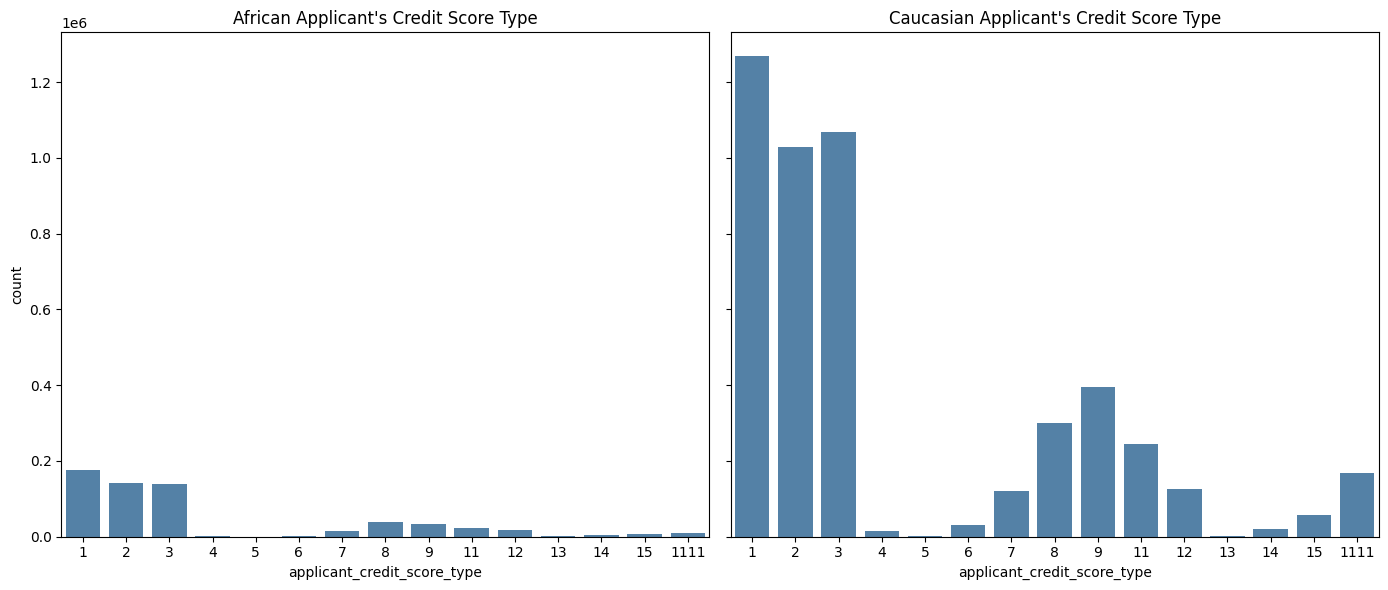

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use the correct HMDA column name
score_col = 'applicant_credit_score_type' 

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot for African applicants
sns.countplot(data=data[data['race'] == 'African-American'], x=score_col, ax=axes[0], color='steelblue')
axes[0].set_title("African Applicant's Credit Score Type")

# Plot for Caucasian applicants
sns.countplot(data=data[data['race'] == 'Caucasian'], x=score_col, ax=axes[1], color='steelblue')
axes[1].set_title("Caucasian Applicant's Credit Score Type")

plt.tight_layout()
plt.show()

## Model Training and Testing<a id="model"></a>

In [36]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=['target','race','gender'])
y = data['target']

# Standard 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
print(X.columns.tolist())

['loan_type', 'loan_purpose', 'applicant_credit_score_type', 'ffiec_msa_md_median_family_income', 'relative_income', 'dti_category']


In [38]:
# 1. Define 'features' by dropping the target column
# This ensures you don't include the answer (target) in your input data
features = data.drop(columns=['target', 'race', 'gender'])

# 2. Select only columns with numeric data types
# FIX: Call select_dtypes directly on the 'features' DataFrame
numeric_features = features.select_dtypes(include=['number']).columns.tolist()

# 3. Select only columns with categorical/string data types
# FIX: Call select_dtypes directly on the 'features' DataFrame
categorical_features = features.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric Features: {numeric_features}")
print(f"Categorical Features: {categorical_features}")

Numeric Features: ['loan_type', 'loan_purpose', 'applicant_credit_score_type', 'ffiec_msa_md_median_family_income', 'relative_income']
Categorical Features: ['dti_category']


In [39]:
from sklearn. preprocessing import StandardScaler, OneHotEncoder
from sklearn. compose import ColumnTransformer

preprocessor = ColumnTransformer ([("num", StandardScaler(), numeric_features),
("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),])

In [40]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Calculate the exact imbalance ratio
# XGBoost's scale_pos_weight affects the POSITIVE class (usually 1 / Approved)
# If Approvals heavily outnumber Denials, this fraction will correctly penalize over-approving.
num_denied = (y_train == 0).sum()
num_approved = (y_train == 1).sum()
imbalance_ratio = num_denied / num_approved 

# Create the XGBoost Pipeline
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor), # Using your existing ColumnTransformer
    ("classifier", XGBClassifier(
        scale_pos_weight=imbalance_ratio,
        random_state=42,
        n_jobs=-1 # Uses all CPU cores to run much faster
    ))
])

# Define a small search grid for tuning
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [4, 6, 8],
    'classifier__learning_rate': [0.05, 0.1, 0.2]
}

# Set up the Random Search, optimizing specifically for F1-Score
print("Starting Hyperparameter Tuning...")
search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_grid,
    n_iter=5, # Number of random combinations to try
    scoring='f1', # Forces the model to balance Precision and Recall
    cv=3, 
    verbose=1,
    random_state=42
)

# Fit the search to find the best model
search.fit(X_train, y_train)
best_model = search.best_estimator_

print(f"\nBest Parameters Found: {search.best_params_}")

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best Parameters Found: {'classifier__n_estimators': 200, 'classifier__max_depth': 8, 'classifier__learning_rate': 0.05}


# 1. Foundations of the Alignment Problem<a id="1"></a>

* **Alignment Gap & Impossibility Theorem:** Exploring the mathematical tension between fairness, accuracy, and calibration.
* **Group-Conditional Error Rates:** Analyzing False Positive Rates (FPR) and False Negative Rates (FNR) across protected classes.

ROC AUC Score: 0.7816


<Figure size 800x600 with 0 Axes>

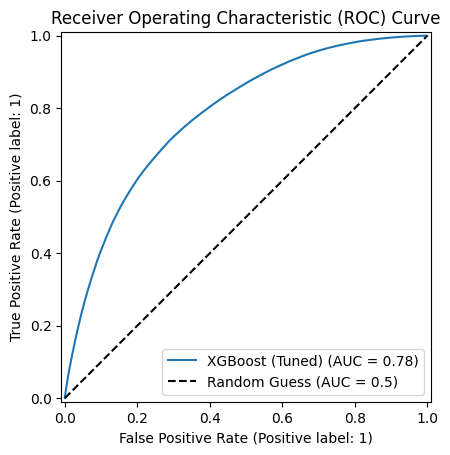

In [41]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# 1. Get predicted probabilities for the positive class (class 1)
# The [:, 1] extracts the probabilities specifically for the 'Approved' class
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# 2. Calculate and print the exact ROC AUC Score
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {auc_score:.4f}")

# 3. Plot the ROC Curve
plt.figure(figsize=(8, 6))
# RocCurveDisplay is the modern scikit-learn way to plot this directly from the estimator
display = RocCurveDisplay.from_estimator(best_model, X_test, y_test, name="XGBoost (Tuned)")

# Add a diagonal line representing a random guess baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score

# 1. Create the Logistic Regression Pipeline
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor), # Re-using your exact column transformer
    ("classifier", LogisticRegression(
        class_weight='balanced', # Handles the 80/20 class imbalance
        random_state=42,
        max_iter=1000 # Increased to ensure convergence 
    ))
])

# 2. Train the baseline model
print("Training Logistic Regression Baseline...")
lr_pipeline.fit(X_train, y_train)

# 3. Make predictions
lr_preds = lr_pipeline.predict(X_test)
lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]

# 4. Calculate Baseline Metrics
lr_f1 = f1_score(y_test, lr_preds)
lr_auc = roc_auc_score(y_test, lr_probs)

# 5. Predict with your existing best_model (XGBoost) for direct comparison
xgb_preds = best_model.predict(X_test)
xgb_probs = best_model.predict_proba(X_test)[:, 1]

xgb_f1 = f1_score(y_test, xgb_preds)
xgb_auc = roc_auc_score(y_test, xgb_probs)

# 6. Print the Comparison
print("\n─── Model Comparison ───")
print(f"Logistic Regression (Baseline):")
print(f"  F1-Score : {lr_f1:.4f}")
print(f"  ROC-AUC  : {lr_auc:.4f}")

print(f"\nXGBoost:")
print(f"  F1-Score : {xgb_f1:.4f}")
print(f"  ROC-AUC  : {xgb_auc:.4f}")

# Lift calculations
print(f"\nPerformance Lift from XGBoost:")
print(f"  F1 Lift  : +{(xgb_f1 - lr_f1):.4f}")
print(f"  AUC Lift : +{(xgb_auc - lr_auc):.4f}")

Training Logistic Regression Baseline...

─── Model Comparison ───
Logistic Regression (Baseline):
  F1-Score : 0.7729
  ROC-AUC  : 0.6654

XGBoost:
  F1-Score : 0.8039
  ROC-AUC  : 0.7816

Performance Lift from XGBoost:
  F1 Lift  : +0.0311
  AUC Lift : +0.1163


## 2. Alignment Gap & Impossibility Theorem 
-  Exploring the mathematical tension between fairness, accuracy, and calibration.

In [43]:
import pandas as pd, numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

print(f"N = {len(data):,}")

# Use these columns for your head() check
print("── HMDA Key Features Preview ──────────────────────────────────────")
cols_to_view = ['race', 'gender', 'dti_category', 'target']

# This gives you a clear look at the data before you run the Fairness Audit
print(data[cols_to_view].head())

N = 6,147,044
── HMDA Key Features Preview ──────────────────────────────────────
        race  gender dti_category  target
0  Caucasian    Male     mid_risk     1.0
1  Caucasian   Joint     mid_risk     1.0
2  Caucasian  Female    high_risk     1.0
3  Caucasian   Joint     low_risk     1.0
4  Caucasian    Male     mid_risk     1.0


In [44]:
# 1. Add the predictions back to the DataFrame
data['pred_class'] = best_model.predict(X)

# 2. Create the Confusion Matrix
# 'target' is the Actual outcome, 'pred_class' is what your model predicted
overall_cm = pd.crosstab(
    data['pred_class'],
    data['target'],
    rownames=['Predicted'],
    colnames=['Actual']
)

print("── Overall Confusion Matrix (Approved=1, Denied=0) ──────────────────")
print(overall_cm)

# 3. Extract values
# We use the integer keys (1 and 0) which match your binary target
# TP: Predicted Approved (1), Actually Approved (1)
# TN: Predicted Denied (0), Actually Denied (0)
tp = overall_cm.loc[1, 1]
tn = overall_cm.loc[0, 0]
fp = overall_cm.loc[1, 0]
fn = overall_cm.loc[0, 1]
n  = overall_cm.values.sum()

# 4. Print metrics formatted for your Final Report
print(f"\nAccuracy  : {(tp + tn) / n:.3f}")
print(f"Precision : {tp / (tp + fp):.3f}")  # Ability to find only true approvals
print(f"Recall    : {tp / (tp + fn):.3f}")  # Ability to find all true approvals
print(f"FPR       : {fp / (fp + tn):.3f}")  # False Positive Rate (Unfair approval)
print(f"FNR       : {fn / (fn + tp):.3f}")  # False Negative Rate (Unfair denial)

── Overall Confusion Matrix (Approved=1, Denied=0) ──────────────────
Actual        0.0      1.0
Predicted                 
0          756269  1457095
1          305496  3628184

Accuracy  : 0.713
Precision : 0.922
Recall    : 0.713
FPR       : 0.288
FNR       : 0.287


## **Group-Conditional Error Rates:** 
- Analyzing False Positive Rates (FPR) and False Negative Rates (FNR) across protected classes.

In [45]:
print("\n\n── Fairness Audit: Confusion Matrix by Race ──────────────────────────\n")

# 1. Calculate base counts and metrics grouped by Race
# We assume 'target' and 'pred_class' are both integers (0 and 1)
race_metrics = (
    data.assign(
        actual=lambda x: x['target'].astype(int),
        pred=lambda x: x['pred_class'].astype(int)
    )
    .assign(
        is_TP=lambda x: (x['pred'] == 1) & (x['actual'] == 1), # True Approval
        is_TN=lambda x: (x['pred'] == 0) & (x['actual'] == 0), # True Denial
        is_FP=lambda x: (x['pred'] == 1) & (x['actual'] == 0), # False Approval
        is_FN=lambda x: (x['pred'] == 0) & (x['actual'] == 1)  # False Denial (The "Unfair" Denial)
    )
    .groupby('race')
    .agg(
        n=('race', 'size'),
        TP=('is_TP', 'sum'),
        TN=('is_TN', 'sum'),
        FP=('is_FP', 'sum'),
        FN=('is_FN', 'sum')
    )
    .assign(
        Accuracy=lambda x: ((x['TP'] + x['TN']) / x['n']).round(3),
        Precision=lambda x: (x['TP'] / (x['TP'] + x['FP'])).round(3),
        Recall=lambda x: (x['TP'] / (x['TP'] + x['FN'])).round(3),
        FPR=lambda x: (x['FP'] / (x['FP'] + x['TN'])).round(3), # False Positive Rate
        FNR=lambda x: (x['FN'] / (x['FN'] + x['TP'])).round(3)  # False Negative Rate
    )
    .sort_values(by='n', ascending=False)
    .reset_index()
)

# Display the table
print(race_metrics.to_string(index=False))

# 2. Print a quick Disparate Impact check
try:
    white_fnr = race_metrics.loc[race_metrics['race'] == 'Caucasian', 'FNR'].values[0]
    black_fnr = race_metrics.loc[race_metrics['race'] == 'African-American', 'FNR'].values[0]
    fnr_ratio = black_fnr / white_fnr if white_fnr > 0 else 0
    
    print(f"\n--- Equality of Opportunity Check ---")
    print(f"African-American FNR: {black_fnr}")
    print(f"Caucasian FNR: {white_fnr}")
    print(f"FNR Ratio (Black/White): {fnr_ratio:.2f}x")
    print("Interpretation: A ratio > 1.0 means Black applicants are 'falsely denied' more often.")
except:
    print("\nNote: Ensure 'African' and 'Caucasian' labels match your race column values.")



── Fairness Audit: Confusion Matrix by Race ──────────────────────────

            race       n      TP     TN     FP      FN  Accuracy  Precision  Recall   FPR   FNR
       Caucasian 4839398 2857544 554938 222079 1204837     0.705      0.928   0.703 0.286 0.297
African-American  607746  293184 126593  45705  142264     0.691      0.865   0.673 0.265 0.327
           Asian  447307  323013  40049  23559   60686     0.812      0.932   0.842 0.370 0.158
           Joint  167172  112334  16369   8441   30028     0.770      0.930   0.789 0.340 0.211
        Minority   85421   42109  18320   5712   19280     0.707      0.881   0.686 0.238 0.314

--- Equality of Opportunity Check ---
African-American FNR: 0.327
Caucasian FNR: 0.297
FNR Ratio (Black/White): 1.10x
Interpretation: A ratio > 1.0 means Black applicants are 'falsely denied' more often.


#### Compare model performance by race

In [46]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

def group_metrics(pipeline, X, y, groups, group_name="race"):
    results = []
    X_ = X.copy()
    
    # Add the evaluation columns
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]
    
    # Temporarily add the protected attribute just for this analysis dataframe
    # Using .values ensures we don't get misaligned index errors if indices differ slightly
    X_[group_name] = groups.values 

    for group, gdf in X_.groupby(group_name, observed=False):
        tn, fp, fn, tp = confusion_matrix(gdf["actual"], gdf["pred"]).ravel()
        
        results.append({
            group_name : group,
            "n" : len(gdf),
            "accuracy" : round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR" : round(fp / (fp + tn), 3),
            "FNR" : round(fn / (fn + tp), 3),
            "AUC" : round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3),
        })
        
    return pd.DataFrame(results).sort_values("n", ascending=False)

In [47]:
# Assuming 'original_df' is your full dataframe before you dropped 'race'
# We use X_test.index to grab the exact rows that ended up in the test set
race_test_labels = data.loc[X_test.index, 'race']

# Now pass those labels into your new 'groups' parameter
print(group_metrics(
    pipeline=best_model, 
    X=X_test, 
    y=y_test, 
    groups=race_test_labels, 
    group_name="race"
))

               race       n  accuracy    FPR    FNR    AUC
2         Caucasian  967420     0.704  0.289  0.297  0.778
0  African-American  121707     0.691  0.268  0.326  0.770
1             Asian   89696     0.811  0.377  0.158  0.798
3             Joint   33575     0.764  0.342  0.217  0.795
4          Minority   17011     0.705  0.245  0.314  0.795


# 2. Explainability and Interpretability<a id="2"></a>

* **Interpretable-by-Design Models:** Utilizing Generalized Linear Models (GLMs) and Generalized Additive Models (GAMs) for inherent transparency.
* **Post-Hoc Explanations:** Applying LIME and SHAP to interrogate complex "black-box" ensembles.
* **Counterfactuals & Recourse:** Implementing Diverse Counterfactual Explanations (DiCE) to provide actionable feedback for denied applicants.

### Interpretable-by-Design Models (GLMs & GAMs)<a id="interpretable-by-design-models"></a>

#### Post-Hoc Explanations (LIME & SHAP)<a id="post-hoc-explanations"></a>


In [48]:
### LIME explanations: Black vs White defendant
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

# --- 1. EXTRACT THE FITTED PREPROCESSOR ---
fitted_preprocessor = best_model.named_steps["preprocessor"] 

# Transform training data using the FITTED preprocessor
X_train_sample = X_train.sample(5000, random_state=42)
X_train_enc = fitted_preprocessor.transform(X_train_sample)

if hasattr(X_train_enc, "toarray"): 
    X_train_enc = X_train_enc.toarray()

# --- 2. RECONSTRUCT FEATURE NAMES ---
# Use the fitted_preprocessor to get the feature names
feature_names = numeric_features + list(
    fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
)

# Initialize the Explainer (No changes needed here)
explainer = LimeTabularExplainer(
    training_data=X_train_enc,
    feature_names=feature_names,
    class_names=["Denied", "Approved"], 
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# --- Selection Logic for Comparison (CORRECTED) ---
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = best_model.predict_proba(X_test)[:, 1]

# BRING BACK THE RACE COLUMN FROM THE ORIGINAL DATAFRAME
# Replace 'original_df' with whatever your starting dataframe was named
X_test_copy["race"] = data.loc[X_test.index, "race"]

# Now your filtering will work perfectly
african_df = X_test_copy[X_test_copy['race'] == 'African-American'].sort_values("pred_prob")
caucasian_df = X_test_copy[X_test_copy['race'] == 'Caucasian'].sort_values("pred_prob")

african_idx = african_df.index[len(african_df) // 2]
caucasian_idx = caucasian_df.index[len(caucasian_df) // 2]

# Generate LIME explanations
for label, idx in [("African Applicant", african_idx), ("Caucasian Applicant", caucasian_idx)]:
    print(f"\n--- {label} (Index: {idx}) ---")

    # --- 3. TRANSFORM TEST ROW ---
    # Use the FITTED preprocessor here as well
    row_enc = fitted_preprocessor.transform(X_test.loc[[idx]])
    
    if hasattr(row_enc, "toarray"):
        row_enc = row_enc.toarray()

    # explain_instance needs the raw classifier because row_enc is already preprocessed
    exp = explainer.explain_instance(
        data_row=row_enc[0],
        predict_fn=best_model.named_steps["classifier"].predict_proba,
        num_features=6
    )

    # Output the top features contributing to the decision
    for feat, weight in exp.as_list():
        print(f"{feat:<40} {weight:+.4f}")


--- African Applicant (Index: 34608) ---
dti_category_extreme_risk <= 0.00        +0.2634
loan_type <= -0.45                       +0.0652
-0.00 < relative_income <= -0.00         +0.0552
loan_purpose > -0.34                     +0.0503
dti_category_high_risk > 0.00            -0.0467
-0.08 < ffiec_msa_md_median_family_income <= 0.46 +0.0272

--- Caucasian Applicant (Index: 5653590) ---
dti_category_extreme_risk > 0.00         -0.2610
ffiec_msa_md_median_family_income <= -0.64 -0.0653
loan_type > -0.45                        -0.0633
-0.00 < relative_income <= -0.00         +0.0599
loan_purpose <= -0.58                    -0.0449
dti_category_high_risk <= 0.00           +0.0447


In [49]:
from IPython.display import display, HTML

# 1. Update labels to match your HMDA terminology (African/Caucasian)
# Ensure african_idx and caucasian_idx were successfully defined in the previous step
for label, idx in [("African Applicant", african_idx), ("Caucasian Applicant", caucasian_idx)]:
    print(f"\n--- {label} (Index: {idx}) ---")

    # 2. Transform the specific row using your FITTED preprocessor
    # We use .loc[[idx]] to keep it as a DataFrame, which preprocessor expects
    row_enc = best_model.named_steps["preprocessor"].transform(X_test.loc[[idx]])
    
    # Convert sparse output from OneHotEncoder to dense for LIME
    if hasattr(row_enc, "toarray"):
        row_enc = row_enc.toarray()

    # 3. Generate the explanation
    # predict_fn should be the classifier's probability function 
    # because row_enc is already in the 'processed' numeric state
    exp = explainer.explain_instance(
        data_row=row_enc[0],
        predict_fn=best_model.named_steps["classifier"].predict_proba,
        num_features=10 # Increased to see more mortgage factors like DTI and Loan Amount
    )

    # 4. Display the interactive visualization
    print(f"LIME Explanation for {label}")
    display(HTML(exp.as_html()))


--- African Applicant (Index: 34608) ---
LIME Explanation for African Applicant



--- Caucasian Applicant (Index: 5653590) ---
LIME Explanation for Caucasian Applicant


Generating Global Summary Plot...


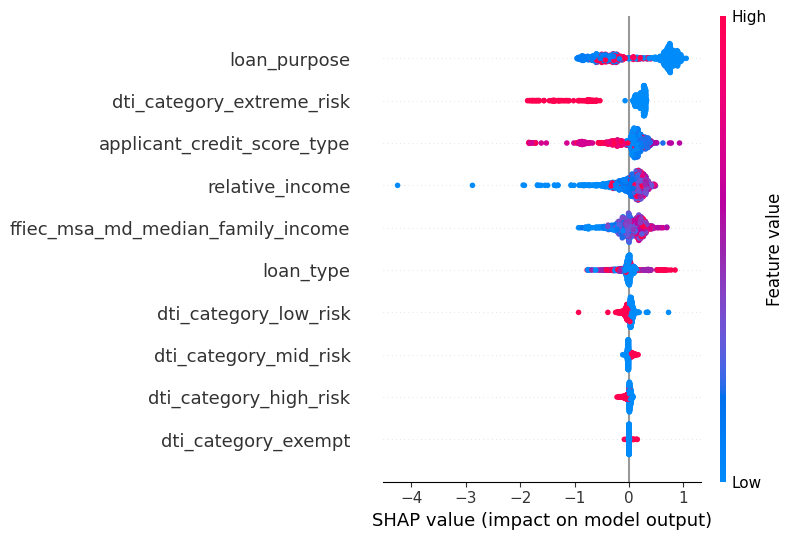


--- SHAP Waterfall: African Applicant (Index: 34608) ---


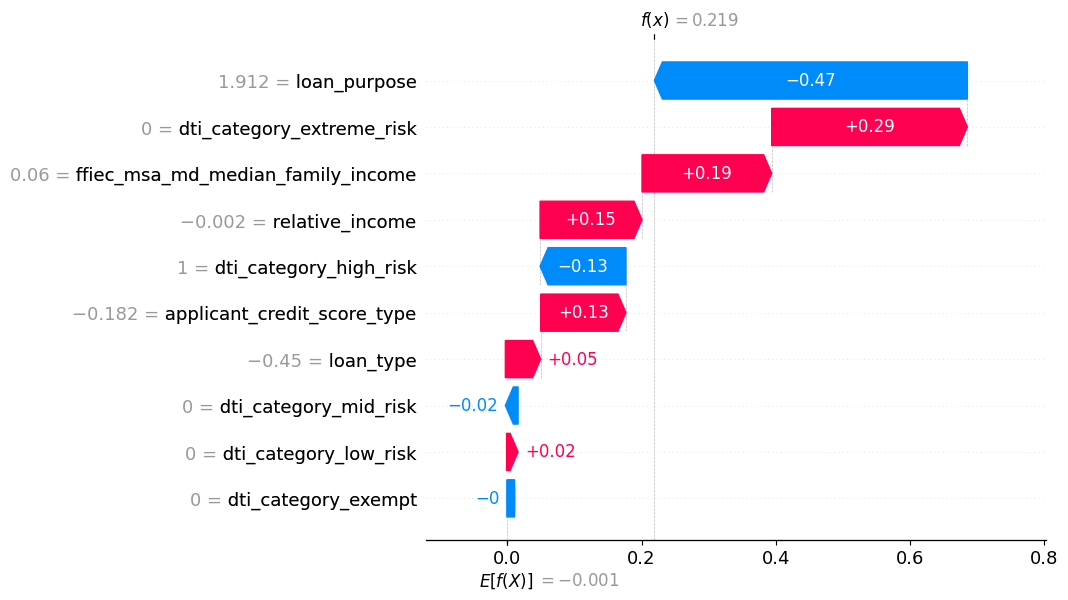


--- SHAP Waterfall: Caucasian Applicant (Index: 5653590) ---


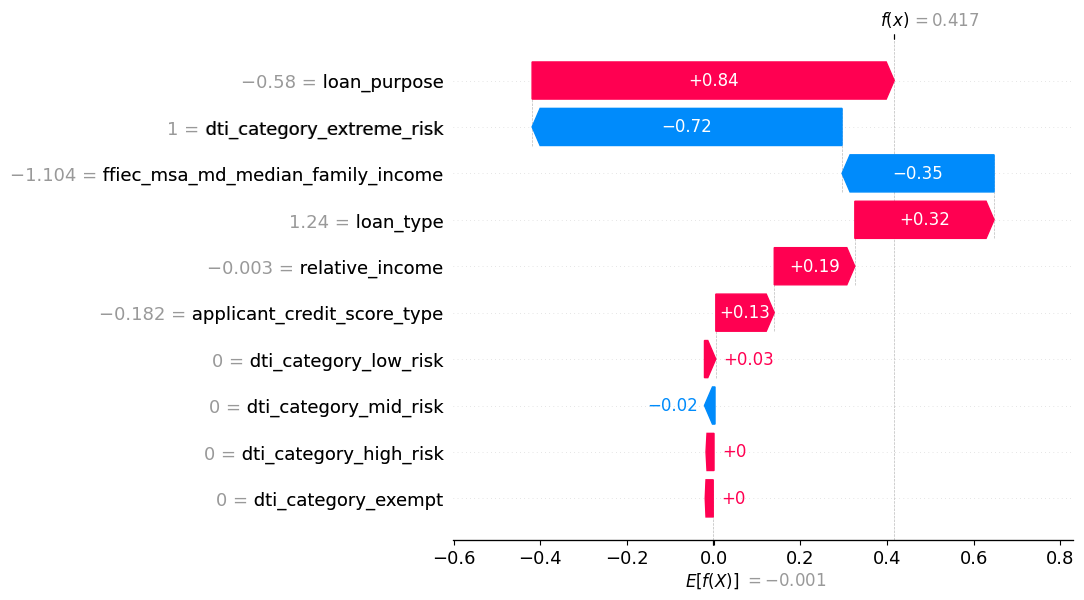

In [50]:
#### SHAP beeswarm and waterfall:  Black vs White
import shap
import matplotlib.pyplot as plt
import numpy as np

# --- 1. EXTRACT THE FITTED PREPROCESSOR ---
fitted_preprocessor = best_model.named_steps["preprocessor"]

# Sample the test data for global explanation
X_test_sample = X_test.sample(1000, random_state=42)
X_test_enc = fitted_preprocessor.transform(X_test_sample)

# --- 2. HANDLE SPARSE MATRICES ---
# TreeExplainer prefers dense arrays
if hasattr(X_test_enc, "toarray"):
    X_test_enc = X_test_enc.toarray()

# 3. Reconstruct Feature Names from the ColumnTransformer
feat_names = numeric_features + list(
    fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
)

# 4. Initialize TreeExplainer
# TreeExplainer is much faster than KernelExplainer for GBT models.
explainer_shap = shap.TreeExplainer(best_model.named_steps["classifier"])

# 5. Calculate SHAP values
shap_values = explainer_shap.shap_values(X_test_enc)

# 6. Global Summary (Beeswarm) Plot
if isinstance(shap_values, list):
    shap_to_plot = shap_values[1]
else:
    shap_to_plot = shap_values

print("Generating Global Summary Plot...")
shap.summary_plot(shap_to_plot, X_test_enc, feature_names=feat_names)

# 7. Individual Waterfall Plots (Local Explanations)
for label, idx in [("African Applicant", african_idx), ("Caucasian Applicant", caucasian_idx)]:
    # Transform the specific row using the FITTED preprocessor
    row_enc = fitted_preprocessor.transform(X_test.loc[[idx]])
    
    # Ensure it's dense
    if hasattr(row_enc, "toarray"):
        row_enc = row_enc.toarray()
        
    row_shap = explainer_shap.shap_values(row_enc)
    
    # Handle SHAP output format consistency
    if isinstance(row_shap, list):
        row_values = row_shap[1][0]
        base_val = explainer_shap.expected_value[1]
    else:
        row_values = row_shap[0]
        base_val = explainer_shap.expected_value

    # Create the Explanation object (required for waterfall_plot)
    explanation = shap.Explanation(
        values=row_values, 
        base_values=base_val, 
        data=row_enc[0], 
        feature_names=feat_names
    )
    
    print(f"\n--- SHAP Waterfall: {label} (Index: {idx}) ---")
    shap.waterfall_plot(explanation, max_display=10)

## Counterfactuals & Recourse (DiCE)<a id="counterfactuals--recourse"></a>

In [51]:
### Counterfactuals with DiCE: Black vs White
import dice_ml
from dice_ml import Dice

# 1. Define the outcome name as a string
# In your HMDA dataset, the target column is usually named 'target'
outcome_column_name = 'target' 

# 2. Setup DiCE Data
# We use a sample for dice_data because DiCE is computationally heavy
# and doesn't need all 6 million rows to understand the feature ranges
dice_data = dice_ml.Data(
    dataframe=pd.concat([X_train, y_train], axis=1).sample(5000, random_state=42),
    continuous_features=numeric_features,
    outcome_name=outcome_column_name
)

# 3. Setup DiCE Model
# Note: Use the whole pipeline (best_model) so DiCE understands the transformations
dice_model = dice_ml.Model(
    model=best_model, 
    backend="sklearn", 
    model_type="classifier"
)

# 4. Initialize DiCE
# 'random' is faster for large feature sets
exp_dice = Dice(dice_data, dice_model, method="random")

# 5. Generate Counterfactuals for your African Applicant
# This shows: "If your income was X higher, you would have been approved"
print(f"Generating counterfactuals for Index: {african_idx}")
query_instance = X_test.loc[[african_idx]]
dice_exp = exp_dice.generate_counterfactuals(
    query_instance, 
    total_CFs=3, 
    desired_class="opposite"
)

print(f"Generating counterfactuals for Index: {caucasian_idx}")
query_instance = X_test.loc[[caucasian_idx]]
dice_exp = exp_dice.generate_counterfactuals(
    query_instance, 
    total_CFs=3, 
    desired_class="opposite"
)

# Visualize the counterfactuals
dice_exp.visualize_as_dataframe(show_only_changes=True)

Generating counterfactuals for Index: 34608


100%|██████████| 1/1 [00:00<00:00, 27.54it/s]


Generating counterfactuals for Index: 5653590


100%|██████████| 1/1 [00:00<00:00, 32.87it/s]

Query instance (original outcome : 1)


,loan_type,loan_purpose,applicant_credit_score_type,ffiec_msa_md_median_family_income,relative_income,dti_category,target
0,2,1,3,76400,1.138743,extreme_risk,1



Diverse Counterfactual set (new outcome: 0)


,loan_type,loan_purpose,applicant_credit_score_type,ffiec_msa_md_median_family_income,relative_income,dti_category,target
0,-,24,-,-,5.1,-,0
1,1,-,421,-,-,-,0
2,-,28,-,-,-,mid_risk,0


In [52]:
# 2. Define the cases
test_cases = [("African Applicant", african_idx), ("Caucasian Applicant", caucasian_idx)]

# Ensure target is an integer
data['target'] = data['target'].astype(int)

for label, idx in test_cases:
    print(f"\n--- Counterfactual for: {label}, Index: {idx} ---")
    query_instance = X_test.loc[[idx]]
    
    # Check the actual prediction first
    current_pred = best_model.predict(query_instance)[0]
    print(f"Current Model Prediction: {current_pred}")
    
    try:
        # Attempt 1: Strict features
        dice_exp = exp_dice.generate_counterfactuals(
            query_instance, 
            total_CFs=2, 
            desired_class="opposite", # Automatically looks for the flipped outcome
            features_to_vary=['loan_to_income_ratio', 'dti_category', 'relative_income']
        )
        print("Success! Found counterfactuals within restricted features.")
        dice_exp.visualize_as_dataframe(show_only_changes=True)
        
    except Exception as e:
        print("Could not find a valid counterfactual by only changing DTI and Income.")
        print("Attempting to find a counterfactual by allowing ALL features to vary...")
        
        try:
            # Attempt 2: Allow all features to vary to see what it actually takes
            dice_exp_fallback = exp_dice.generate_counterfactuals(
                query_instance, 
                total_CFs=2, 
                desired_class="opposite" 
            )
            dice_exp_fallback.visualize_as_dataframe(show_only_changes=True)
        except Exception as e:
            print(f"Even with all features varied, no counterfactual was found. Error: {e}")


--- Counterfactual for: African Applicant, Index: 34608 ---
Current Model Prediction: 1


  0%|          | 0/1 [00:00<?, ?it/s]

Could not find a valid counterfactual by only changing DTI and Income.
Attempting to find a counterfactual by allowing ALL features to vary...


100%|██████████| 1/1 [00:00<00:00, 32.50it/s]

Query instance (original outcome : 1)


...

100%|██████████| 1/1 [00:00<00:00, 34.41it/s]

Query instance (original outcome : 1)


,loan_type,loan_purpose,applicant_credit_score_type,ffiec_msa_md_median_family_income,relative_income,dti_category,target
0,2,1,3,76400,1.138743,extreme_risk,1



Diverse Counterfactual set (new outcome: 0)


,loan_type,loan_purpose,applicant_credit_score_type,ffiec_msa_md_median_family_income,relative_income,dti_category,target
0,-,-,605,-,-,-,0
1,-,-,753,-,-,-,0


In [53]:
# 1. Setup Data - Ensure categorical features are explicitly defined
# DiCE needs to know 'dti_category' is categorical to sample valid categories
d_data = dice_ml.Data(
    dataframe=pd.concat([X_train, y_train], axis=1).sample(5000, random_state=42),
    continuous_features=numeric_features, 
    categorical_features=['dti_category'], # <-- CRITICAL FIX ADDED
    outcome_name='target' 
)

# Switch to 'genetic' method - much better at finding narrow approval boundaries
d_model = dice_ml.Model(model=best_model, backend="sklearn")
exp_dice = Dice(d_data, d_model, method="genetic") # <-- CRITICAL FIX ADDED

# 2. Define the cases
test_cases = [("African Applicant", african_idx), ("Caucasian Applicant", caucasian_idx)]

# Ensure target is an integer
data['target'] = data['target'].astype(int)

for label, idx in test_cases:
    print(f"\n--- Counterfactual for: {label}, Index: {idx} ---")
    query_instance = X_test.loc[[idx]]
    
    # Print the current prediction so you know what you are trying to flip
    current_pred = best_model.predict(query_instance)[0]
    print(f"Current Model Prediction: {current_pred}")
    
    try:
        # Attempt 1: Strict features (Only DTI, Loan-to-Income, Relative Income)
        dice_exp = exp_dice.generate_counterfactuals(
            query_instance, 
            total_CFs=2, 
            desired_class="opposite", 
            features_to_vary=['loan_to_income_ratio', 'dti_category', 'relative_income']
        )
        print("Success! Found counterfactuals within restricted features.")
        dice_exp.visualize_as_dataframe(show_only_changes=True)
        
    except Exception as e:
        # Fallback if changing those 3 features isn't enough to secure an approval
        print("\nCould not find a valid counterfactual by only changing DTI and Income.")
        print("Attempting to find a counterfactual by allowing ALL features to vary...")
        
        try:
            # Attempt 2: Allow all features to vary to see what it actually takes
            dice_exp_fallback = exp_dice.generate_counterfactuals(
                query_instance, 
                total_CFs=2, 
                desired_class="opposite" 
            )
            dice_exp_fallback.visualize_as_dataframe(show_only_changes=True)
        except Exception as e:
            print(f"Even with all features varied, no counterfactual was found. Error: {e}")


--- Counterfactual for: African Applicant, Index: 34608 ---
Current Model Prediction: 1


  0%|          | 0/1 [00:00<?, ?it/s]



Could not find a valid counterfactual by only changing DTI and Income.
Attempting to find a counterfactual by allowing ALL features to vary...


100%|██████████| 1/1 [00:00<00:00, 24.32it/s]

Query instance (original outcome : 1)


...

100%|██████████| 1/1 [00:00<00:00, 25.28it/s]

Query instance (original outcome : 1)


,loan_type,loan_purpose,applicant_credit_score_type,ffiec_msa_md_median_family_income,relative_income,dti_category,target
0,2,1,3,76400,1.138743,extreme_risk,1



Diverse Counterfactual set (new outcome: 0)


,loan_type,loan_purpose,applicant_credit_score_type,ffiec_msa_md_median_family_income,relative_income,dti_category,target
0,-,-,9,-,0.6,-,0
0,1,-,1,-,1.5,-,0


# 3. Algorithmic Bias Measurement<a id="3"></a>

* **Disparity Metrics:** Calculating Adverse Impact Ratio (AIR), Marginal Effect (ME), and Standardized Mean Difference (SMD).
* **Intersectional Subgroup Testing:** Moving beyond single-variable bias to examine overlapping identities (e.g., race × gender).

### Disparity Metrics (AIR, ME, SMD)<a id="#disparity-metrics-air-me-smd"></a>

In [54]:
def calculate_disparate_impact(data, group_col, outcome_col, ref_group):
    """
    Calculates Approval Rates, Adverse Impact Ratio (AIR), 
    and Marginal Effect (ME) relative to a reference group.
    """
    # 1. Calculate the mean of the target (Approval Rate)
    # Ensure target is numeric (1 = Approved, 0 = Denied)
    rates = (data.groupby(group_col)[outcome_col]
             .mean()
             .rename('approval_rate')
             .reset_index())
    
    # 2. Identify the reference group rate (usually Caucasian)
    ref_rate = rates.loc[rates[group_col] == ref_group, 'approval_rate'].values[0]
    
    # 3. Calculate AIR: (Group Rate / Reference Rate)
    rates['AIR'] = rates['approval_rate'] / ref_rate
    
    # 4. Calculate Marginal Effect: (Group Rate - Reference Rate)
    rates['ME'] = rates['approval_rate'] - ref_rate
    
    # 5. Apply the Four-Fifths Rule Flag
    rates['flag_80'] = rates['AIR'].apply(lambda x: '*** DISPARATE IMPACT' if x < 0.80 else '')
    
    return rates

# --- Run the Audit ---
# Use 'race' for the group and 'target' for the binary approval outcome
sir = calculate_disparate_impact(data, 'race', 'target', ref_group='Caucasian')

print("── Disparate Impact Audit (Actual Outcomes) ──────────────────────────")
print(sir.sort_values('AIR').to_string(index=False, justify='left', col_space=12))

── Disparate Impact Audit (Actual Outcomes) ──────────────────────────
race              approval_rate  AIR          ME          flag_80     
African-American 0.716497       0.853542     -0.122943                
        Minority 0.718664       0.856124     -0.120775                
       Caucasian 0.839439       1.000000      0.000000                
           Joint 0.851590       1.014475      0.012151                
           Asian 0.857798       1.021870      0.018359                


In [55]:
def calculate_disparate_impact(data, group_col, outcome_col, ref_group):
    """
    Calculates Approval Rates, Adverse Impact Ratio (AIR), 
    and Marginal Effect (ME) relative to a reference group.
    """
    # 1. Calculate the mean of the target (Approval Rate)
    # Ensure target is numeric (1 = Approved, 0 = Denied)
    rates = (data.groupby(group_col)[outcome_col]
             .mean()
             .rename('approval_rate')
             .reset_index())
    
    # 2. Identify the reference group rate (usually Caucasian)
    ref_rate = rates.loc[rates[group_col] == ref_group, 'approval_rate'].values[0]
    
    # 3. Calculate AIR: (Group Rate / Reference Rate)
    rates['AIR'] = rates['approval_rate'] / ref_rate
    
    # 4. Calculate Marginal Effect: (Group Rate - Reference Rate)
    rates['ME'] = rates['approval_rate'] - ref_rate
    
    # 5. Apply the Four-Fifths Rule Flag
    rates['flag_80'] = rates['AIR'].apply(lambda x: '*** DISPARATE IMPACT' if x < 0.80 else '')
    
    return rates

# --- Run the Audit ---
# Use 'race' for the group and 'target' for the binary approval outcome
sir = calculate_disparate_impact(data, 'gender', 'target', ref_group='Male')

print("── Disparate Impact Audit (Actual Outcomes) ──────────────────────────")
print(sir.sort_values('AIR').to_string(index=False, justify='left', col_space=12))

── Disparate Impact Audit (Actual Outcomes) ──────────────────────────
gender        approval_rate  AIR          ME          flag_80     
Female       0.794660       0.984348     -0.012635                
  Male       0.807296       1.000000      0.000000                
 Joint       0.864833       1.071271      0.057537                


In [56]:
import pandas as pd

def calculate_intersectional_di(X_test, y_pred, race_series, gender_series, reference_group):
    """
    Calculates Disparate Impact for joint race and gender groups.
    
    Parameters:
    X_test: DataFrame containing the test features (to align indices)
    y_pred: Array or Series of the model's binary predictions (1 = Favorable, 0 = Unfavorable)
    race_series: Series containing race labels (from original df)
    gender_series: Series containing gender labels (from original df)
    reference_group: String of the privileged group to compare against (e.g., 'Caucasian_Male')
    """
    
    # 1. Create a sandbox dataframe to hold our metrics safely
    audit_df = pd.DataFrame(index=X_test.index)
    audit_df["pred"] = y_pred
    audit_df["race"] = race_series
    audit_df["gender"] = gender_series
    
    # 2. Combine Race and Gender into a single Intersectional column
    audit_df["intersectional_group"] = audit_df["race"].astype(str) + "_" + audit_df["gender"].astype(str)
    
    # 3. Calculate the favorable outcome rate for every group
    # (Assuming 1 is the favorable outcome, the mean gives us the percentage of 1s)
    success_rates = audit_df.groupby("intersectional_group")["pred"].mean()
    group_counts = audit_df["intersectional_group"].value_counts()
    
    if reference_group not in success_rates:
        raise ValueError(f"Reference group '{reference_group}' not found. Available groups: {list(success_rates.index)}")
        
    ref_success_rate = success_rates[reference_group]
    
    # 4. Calculate the Disparate Impact Ratio
    results = []
    for group in success_rates.index:
        rate = success_rates[group]
        
        # Avoid division by zero if reference group has 0 success
        di_ratio = (rate / ref_success_rate) if ref_success_rate > 0 else 0 
        
        results.append({
            "Group": group,
            "N": group_counts[group],
            "Favorable_Rate": round(rate, 3),
            "Disparate_Impact": round(di_ratio, 3),
            "Fails_80_Rule": "Yes" if di_ratio < 0.8 else "No"
        })
        
    return pd.DataFrame(results).sort_values("Disparate_Impact", ascending=True)

In [57]:
# Assuming 'original_df' has your sensitive columns and 1 = "Approved"
race_labels = data.loc[X_test.index, 'race']
gender_labels = data.loc[X_test.index, 'gender']

# Get the model's hard predictions (0 or 1) rather than probabilities
test_predictions = best_model.predict(X_test)

# Run the audit (adjust the reference_group to match your data's exact text)
di_results = calculate_intersectional_di(
    X_test=X_test, 
    y_pred=test_predictions, 
    race_series=race_labels, 
    gender_series=gender_labels, 
    reference_group="Caucasian_Male" # Example reference group
)
di_results

,Group,N,Favorable_Rate,Disparate_Impact,Fails_80_Rule
12,Minority_Female,5328,0.531,0.859,No
0,African-American_Female,50453,0.543,0.879,No
2,African-American_Male,45510,0.544,0.880,No
14,Minority_Male,8522,0.561,0.907,No
6,Caucasian_Female,218393,0.583,0.943,No
1,African-American_Joint,25744,0.617,0.998,No
8,Caucasian_Male,347846,0.618,1.000,No
13,Minority_Joint,3161,0.628,1.016,No
7,Caucasian_Joint,401181,0.682,1.103,No
10,Joint_Joint,31490,0.712,1.152,No


### AIR and Marginal Effect by race

In [58]:
from statsmodels.stats.proportion import proportions_ztest

# 1. Define the groups as they appear in your cleaned 'race' column
groups = ['African-American', 'Caucasian']

# Filter data to only include these two groups for the test
comparison_data = data[data['race'].isin(groups)]

# 2. ns: Total number of applicants in each group (The Sample Size)
ns = comparison_data.groupby('race')['target'].count()

# 3. events: Number of approvals (target == 1) in each group
events = comparison_data.groupby('race')['target'].sum()

# 4. Perform the z-test
# We use .loc[groups] to ensure the order is consistent
stat, pval = proportions_ztest(
    count=events.loc[groups].values, 
    nobs=ns.loc[groups].values
)

print(f"── Proportions Z-Test: Approval Rates ──────────────────────────────")
print(f"African-American approvals : {int(events.loc['African-American']):,} out of {int(ns.loc['African-American']):,}")
print(f"Caucasian approvals        : {int(events.loc['Caucasian']):,} out of {int(ns.loc['Caucasian']):,}")
print(f"\nZ-statistic : {stat:.3f}")
print(f"P-value     : {pval:.4f}")

# 5. Interpret the result
if pval < 0.05:
    print("\nResult: There is a statistically significant difference in approval proportions.")
    print("This confirms the Disparate Impact observed in the AIR audit is not due to random chance.")
else:
    print("\nResult: No statistically significant difference found (p >= 0.05).")

── Proportions Z-Test: Approval Rates ──────────────────────────────
African-American approvals : 435,448 out of 607,746
Caucasian approvals        : 4,062,381 out of 4,839,398

Z-statistic : -238.143
P-value     : 0.0000

Result: There is a statistically significant difference in approval proportions.
This confirms the Disparate Impact observed in the AIR audit is not due to random chance.


### Standardized Mean Difference

In [59]:
def calculate_smd(data, group_col, score_col, ref_group):
    """Calculates Standardized Mean Difference (Cohen's d) relative to a reference group"""
    # 1. Get the reference group distribution (Caucasian)
    ref = data.loc[data[group_col] == ref_group, score_col]
    results = []
    
    # 2. Iterate through each race group to compare against the baseline
    for grp, g in data.groupby(group_col):
        if grp == ref_group:
            continue
            
        sc = g[score_col]
        
        # 3. Calculate Pooled Standard Deviation
        pooled_std = np.sqrt((ref.var() + sc.var()) / 2)
        
        # 4. Calculate Cohen's d (SMD)
        # d = (Mean_Group - Mean_Ref) / Pooled_Std
        d = ((sc.mean() - ref.mean()) / pooled_std if pooled_std > 0 else 0)
        
        # 5. Interpret Magnitude (Standard Cohen's d thresholds)
        abs_d = abs(d)
        mag = ('negligible' if abs_d < 0.2 else 
               'small' if abs_d < 0.5 else 
               'medium' if abs_d < 0.8 else 
               'large')
        
        results.append({
            group_col: grp,
            'mean_feature_val': round(sc.mean(), 3),
            'SMD': round(d, 3),
            'magnitude': mag
        })
        
    return pd.DataFrame(results)

# --- Run the Analysis ---
# We use 'loan_to_income_ratio' to see the "gap" in financial profiles
smd_tbl = calculate_smd(data, 'race', 'relative_income', ref_group='Caucasian')

print("── Standardized Mean Difference (SMD) by Race ────────────────────────")
print(smd_tbl.sort_values('SMD', ascending=False).to_string(index=False))

── Standardized Mean Difference (SMD) by Race ────────────────────────
            race  mean_feature_val   SMD  magnitude
        Minority             6.842 0.008 negligible
           Asian             2.124 0.004 negligible
           Joint             1.858 0.003 negligible
African-American             2.083 0.001 negligible


### Error Rate Disparity Analysis

In [60]:
import pandas as pd

# 1. Define the Error Rates function for Mortgage Outcomes
def calculate_error_rates(data, group_col, pred_col, outcome_col):
    results = []
    # Group by race and calculate confusion matrix components
    for grp, g in data.groupby(group_col):
        tp = ((g[pred_col] == 1) & (g[outcome_col] == 1)).sum()
        tn = ((g[pred_col] == 0) & (g[outcome_col] == 0)).sum()
        fp = ((g[pred_col] == 1) & (g[outcome_col] == 0)).sum()
        fn = ((g[pred_col] == 0) & (g[outcome_col] == 1)).sum()
        
        results.append({
            group_col: grp, 
            'n': len(g),
            'FPR': fp / (fp + tn) if (fp + tn) > 0 else 0,
            'FNR': fn / (fn + tp) if (fn + tp) > 0 else 0,
            'Accuracy': (tp + tn) / len(g)
        })
    return pd.DataFrame(results)

# 2. Run the analysis using your HMDA columns
# Using 'race' as the group, 'pred_class' from your GBT model, and 'target' as actual
er = calculate_error_rates(data, 'race', 'pred_class', 'target')

print("── Error Rate Analysis by Race ──────────────────────────────────────")
print(er.sort_values('FNR', ascending=False).to_string(index=False))

# 3. Highlight the Disparity for your Capstone Presentation
print("\n── Key Comparison: African-American vs. Caucasian ──────────────────")
for grp in ['African-American', 'Caucasian']:
    # Ensure the string matches your 'race' column labels exactly
    row = er.loc[er['race'] == grp]
    if not row.empty:
        fpr_val = row['FPR'].values[0]
        fnr_val = row['FNR'].values[0]
        acc_val = row['Accuracy'].values[0]
        print(f"{grp:<18} | FPR: {fpr_val:.3f} | FNR: {fnr_val:.3f} | Acc: {acc_val:.3f}")

── Error Rate Analysis by Race ──────────────────────────────────────
            race       n      FPR      FNR  Accuracy
African-American  607746 0.265267 0.326707  0.690711
        Minority   85421 0.237683 0.314063  0.707426
       Caucasian 4839398 0.285810 0.296584  0.705146
           Joint  167172 0.340226 0.210927  0.769884
           Asian  447307 0.370378 0.158160  0.811662

── Key Comparison: African-American vs. Caucasian ──────────────────
African-American   | FPR: 0.265 | FNR: 0.327 | Acc: 0.691
Caucasian          | FPR: 0.286 | FNR: 0.297 | Acc: 0.705


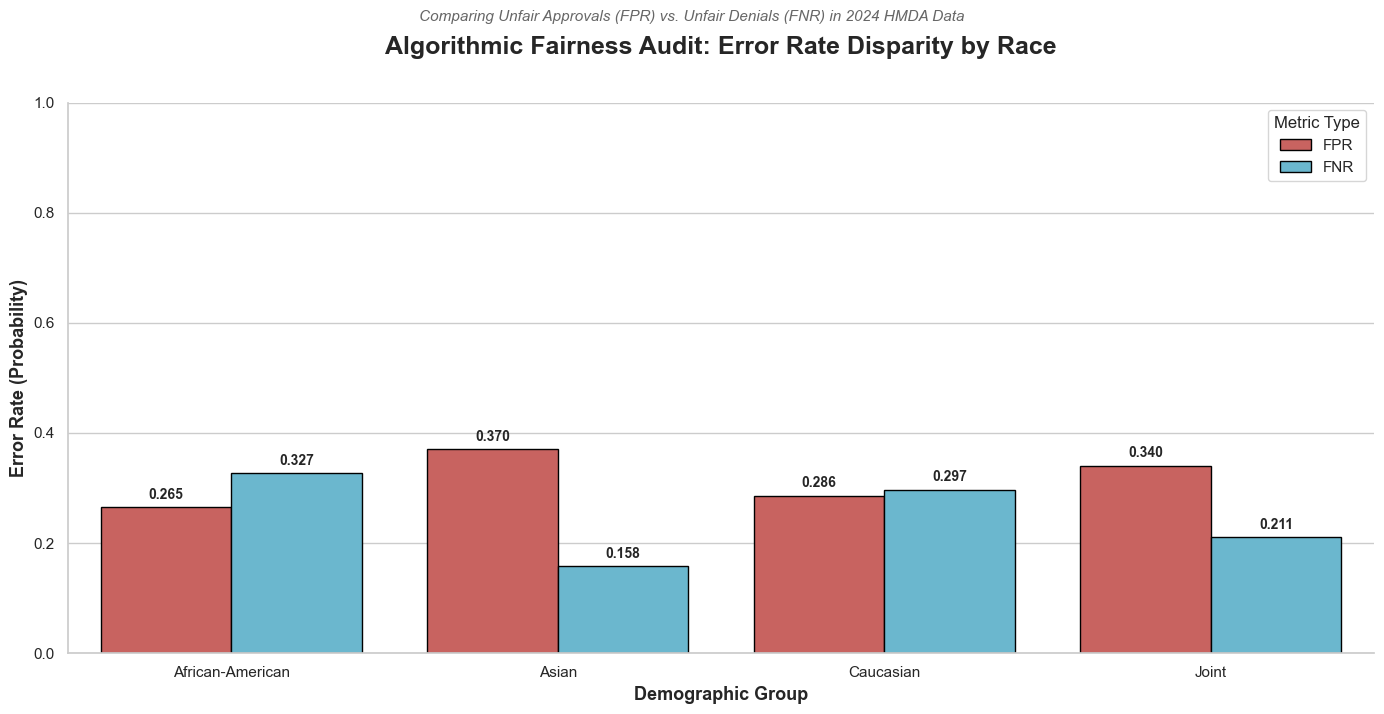

In [61]:
# 1. Filter and Prepare HMDA Race Groups
plot_groups = ['African-American', 'Caucasian', 'Asian', 'Hispanic', 'Joint']
df_plot = er[er['race'].isin(plot_groups)].copy()

# Melt the dataframe for Seaborn grouping
df_melted = df_plot.melt(
    id_vars='race',
    value_vars=['FPR', 'FNR'],
    var_name='Metric',
    value_name='Rate'
)

# 2. Visual Style Setup
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

# 3. Create the Grouped Bar Chart
ax = sns.barplot(
    data=df_melted,
    x='race',
    y='Rate',
    hue='Metric',
    palette=['#d9534f', '#5bc0de'],
    edgecolor='black'
)

# 4. Add Bar Annotations for Precision
for p in ax.patches:
    height = p.get_height()
    if height > 0.001: 
        ax.annotate(
            format(height, '.3f'),
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='center',
            xytext=(0, 9),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold'
        )

# 5. Final Formatting for your MSBA Report
# Increase pad to 35 to give room for the subtitle below it
plt.title('Algorithmic Fairness Audit: Error Rate Disparity by Race', 
          fontsize=18, fontweight='bold', pad=35)

# Set y to 0.94 and adjust fontsize for better hierarchy
plt.suptitle('Comparing Unfair Approvals (FPR) vs. Unfair Denials (FNR) in 2024 HMDA Data', 
             fontsize=11, y=0.92, style='italic', alpha=0.7)

plt.xlabel('Demographic Group', fontsize=13, fontweight='bold')
plt.ylabel('Error Rate (Probability)', fontsize=13, fontweight='bold')
plt.ylim(0, 1.0) # Expanded to 1.0 to ensure labels don't hit the top of the box
plt.legend(title='Metric Type', frameon=True, loc='upper right')

sns.despine()
# Use rect to ensure tight_layout doesn't override the suptitle position
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

### Intersectional Subgroup Testing<a id="#intersectional-subgroup-testing"></a>

In [62]:
# 1. Calculate Approval Rates and Counts by Race and Gender
# We use observed=True to handle categorical data efficiently
sub_rates = (data.groupby(['race', 'gender'], observed=True)['target']
             .agg(['mean', 'count'])
             .rename(columns={'mean': 'approval_rate', 'count': 'n'})
             .reset_index())

# 2. Filter for statistical significance (n >= 30) 
# This ensures we aren't making claims based on tiny sample sizes
sub_rates = sub_rates[sub_rates['n'] >= 30].copy()

# 3. Set a MultiIndex to easily access the reference group (Caucasian Male)
sub_rates = sub_rates.set_index(['race', 'gender'])

# 4. Access the reference rate
# Caucasian Males are the industry standard baseline for Disparate Impact audits
try:
    ref_rate = sub_rates.loc[('Caucasian', 'Male'), 'approval_rate']

    # 5. Calculate AIR and Disparity Flags
    sub_rates['AIR'] = sub_rates['approval_rate'] / ref_rate
    sub_rates['ME'] = sub_rates['approval_rate'] - ref_rate # Marginal Effect
    sub_rates['flag_80'] = sub_rates['AIR'].apply(lambda x: '*** DISPARATE IMPACT' if x < 0.80 else '')

    # 6. Format and Display
    sub_rates_final = sub_rates.reset_index().sort_values('AIR')
    
    print("── Intersectional Fairness Audit: Race & Gender ─────────────────────")
    print(sub_rates_final.to_string(index=False, justify='left', col_space=10))

    # 7. Identify the group with the lowest AIR (Most Disadvantaged)
    worst_idx = sub_rates_final['AIR'].idxmin()
    worst = sub_rates_final.loc[worst_idx]
    
    print(f"\nMost Disadvantaged Group: {worst['race']} {worst['gender']}")
    print(f"Approval Rate: {worst['approval_rate']:.3%}")
    print(f"AIR relative to Caucasian Male: {worst['AIR']:.3f} (n={int(worst['n'])})")

except KeyError:
    print("Error: Reference group ('Caucasian', 'Male') not found in data.")
    print("Available Groups:", sub_rates.index.tolist())

── Intersectional Fairness Audit: Race & Gender ─────────────────────
race             gender      approval_rate  n          AIR        ME        flag_80   
        Minority Female     0.698210         27042    0.853722   -0.119633            
African-American   Male     0.705881        226728    0.863101   -0.111962            
African-American Female     0.708985        252712    0.866896   -0.108858            
        Minority   Male     0.714800         42486    0.874007   -0.103043            
African-American  Joint     0.750051        128306    0.917108   -0.067792            
        Minority  Joint     0.763795         15893    0.933915   -0.054048            
       Caucasian Female     0.812744       1089908    0.993765   -0.005099            
       Caucasian   Male     0.817843       1741574    1.000000    0.000000            
           Joint Female     0.830174          5064    1.015077    0.012331            
           Asian Female     0.838988         98595    1.0258

In [63]:
# 1. Group by both Race and Gender for a "Double Disadvantage" check
intersectional_audit = (
    data.groupby(['race', 'gender'], observed=True)['target']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'approval_rate', 'count': 'n'})
    .reset_index()
)

# 2. Filter for groups with enough data to be statistically sound
intersectional_audit = intersectional_audit[intersectional_audit['n'] >= 50].copy()

# 3. Calculate AIR relative to the 'Caucasian Male' baseline
ref_rate = intersectional_audit.loc[
    (intersectional_audit['race'] == 'Caucasian') & 
    (intersectional_audit['gender'] == 'Male'), 'approval_rate'
].values[0]

intersectional_audit['AIR'] = intersectional_audit['approval_rate'] / ref_rate
intersectional_audit['flag'] = intersectional_audit['AIR'].apply(
    lambda x: '*** DISPARATE IMPACT' if x < 0.80 else ''
)

print("── FINAL INTERSECTIONAL AUDIT ──────────────────────────────────────")
print(intersectional_audit.sort_values('AIR').to_string(index=False))

── FINAL INTERSECTIONAL AUDIT ──────────────────────────────────────
            race gender  approval_rate       n      AIR flag
        Minority Female       0.698210   27042 0.853722     
African-American   Male       0.705881  226728 0.863101     
African-American Female       0.708985  252712 0.866896     
        Minority   Male       0.714800   42486 0.874007     
African-American  Joint       0.750051  128306 0.917108     
        Minority  Joint       0.763795   15893 0.933915     
       Caucasian Female       0.812744 1089908 0.993765     
       Caucasian   Male       0.817843 1741574 1.000000     
           Joint Female       0.830174    5064 1.015077     
           Asian Female       0.838988   98595 1.025854     
           Joint   Male       0.845327    5767 1.033605     
           Asian   Male       0.849098  199408 1.038217     
           Joint  Joint       0.852515  156341 1.042394     
       Caucasian  Joint       0.872662 2007916 1.067028     
           Asian

In [64]:
# 1. Group by both Race and Gender for Intersectionality
intersectional_audit = (
    data.groupby(['race', 'gender'], observed=True)['target']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'approval_rate', 'count': 'n'})
    .reset_index()
)

# 2. Filter for statistical significance (n >= 50)
intersectional_audit = intersectional_audit[intersectional_audit['n'] >= 50].copy()

try:
    # 3. Calculate the Reference Rate (Caucasian Male)
    # We use .loc with a mask to find the specific baseline rate
    ref_mask = (intersectional_audit['race'] == 'Caucasian') & (intersectional_audit['gender'] == 'Male')
    ref_rate = intersectional_audit.loc[ref_mask, 'approval_rate'].values[0]

    # 4. Calculate AIR and Disparity Flags
    intersectional_audit['AIR'] = intersectional_audit['approval_rate'] / ref_rate
    intersectional_audit['ME'] = intersectional_audit['approval_rate'] - ref_rate
    intersectional_audit['flag_80'] = intersectional_audit['AIR'].apply(
        lambda x: '*** DISPARATE IMPACT' if x < 0.80 else ''
    )

    # 5. Print the Full Audit Table
    print("── FINAL INTERSECTIONAL AUDIT: RACE & GENDER ────────────────────────")
    print(intersectional_audit.sort_values('AIR').to_string(index=False, justify='left', col_space=12))

    # 6. Identify the Most Disadvantaged Group (Lowest AIR)
    # We find the row with the minimum AIR
    worst = intersectional_audit.loc[intersectional_audit['AIR'].idxmin()]

    print(f"\n{'='*60}")
    print(f"ANALYSIS SUMMARY")
    print(f"{'='*60}")
    print(f"Most Disadvantaged Group: {worst['race']} {worst['gender']}")
    print(f"Approval Rate           : {worst['approval_rate']:.3%}")
    print(f"AIR vs Caucasian Male   : {worst['AIR']:.3f} (n={int(worst['n'])})")
    
    if worst['AIR'] < 0.80:
        print(f"RESULT: This group falls below the 0.80 threshold for legal Disparate Impact.")
    else:
        print(f"RESULT: This group is above the 0.80 threshold but still shows a {abs(worst['ME']):.1%} gap.")

except (KeyError, IndexError):
    # If 'Caucasian' or 'Male' isn't in the data, list what is available
    print("\n[!] Error: Reference group ('Caucasian', 'Male') not found in filtered data.")
    print("Ensure you have applicants matching this criteria with n >= 50.")
    print("Available Groups in Data:")
    print(intersectional_audit[['race', 'gender']].drop_duplicates())

── FINAL INTERSECTIONAL AUDIT: RACE & GENDER ────────────────────────
race             gender        approval_rate  n            AIR          ME          flag_80     
        Minority Female       0.698210         27042      0.853722     -0.119633                
African-American   Male       0.705881        226728      0.863101     -0.111962                
African-American Female       0.708985        252712      0.866896     -0.108858                
        Minority   Male       0.714800         42486      0.874007     -0.103043                
African-American  Joint       0.750051        128306      0.917108     -0.067792                
        Minority  Joint       0.763795         15893      0.933915     -0.054048                
       Caucasian Female       0.812744       1089908      0.993765     -0.005099                
       Caucasian   Male       0.817843       1741574      1.000000      0.000000                
           Joint Female       0.830174          5064     

# 4. Robustness, Generalization, and Dataset Drift<a id="4"></a>

* **Distribution Shift:** Monitoring model decay using Population Stability Index (PSI), Kolmogorov-Smirnov (KS) tests, and Maximum Mean Discrepancy (MMD).
* **Stress Testing & Sensitivity Analysis:** Evaluating model stability under extreme or synthetic economic scenarios.

### Distribution Shift (PSI, KS, MMD)<a id="distribution-shift-psi-ks-mmd"></a>

In [65]:
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp

def calculate_psi(expected, actual, buckets=10):
    """
    Calculates PSI (Population Stability Index) between two distributions.
    Interpretation: < 0.1: No shift | 0.1-0.2: Moderate shift | > 0.2: Significant shift.
    """
    def scale_range(input_array, min_val, max_val):
        return (input_array - min_val) / (max_val - min_val)

    # Create buckets based on the 'expected' (training) distribution
    breakpoints = np.linspace(0, 1, buckets + 1)
    
    # Calculate frequencies
    expected_percents = np.histogram(scale_range(expected, expected.min(), expected.max()), bins=breakpoints)[0] / len(expected)
    actual_percents = np.histogram(scale_range(actual, actual.min(), actual.max()), bins=breakpoints)[0] / len(actual)

    # Prevent division by zero
    expected_percents = np.clip(expected_percents, a_min=0.0001, a_max=None)
    actual_percents = np.clip(actual_percents, a_min=0.0001, a_max=None)

    # PSI Formula
    psi_value = np.sum((expected_percents - actual_percents) * np.log(expected_percents / actual_percents))
    return psi_value

# 1. Select a feature to test (e.g., income or loan amount)
feature_name = 'relative_income' # Replace with a key numeric feature from your dataset
train_dist = X_train[feature_name]
test_dist = X_test[feature_name]

# 2. Calculate PSI
psi_score = calculate_psi(train_dist, test_dist)

# 3. Kolmogorov-Smirnov (KS) Test
# Null Hypothesis: Distributions are the same. Low p-value = Drift detected.
ks_stat, ks_p_value = ks_2samp(train_dist, test_dist)

print(f"--- Distribution Shift Audit: {feature_name} ---")
print(f"PSI Score: {psi_score:.4f}")
print(f"KS Statistic: {ks_stat:.4f} (p-value: {ks_p_value:.4f})")

if psi_score > 0.1 or ks_p_value < 0.05:
    print("DRIFT DETECTED: The model environment has changed significantly.")
else:
    print("STABLE: No significant distribution shift detected.")

--- Distribution Shift Audit: relative_income ---
PSI Score: 0.0000
KS Statistic: 0.0012 (p-value: 0.1390)
STABLE: No significant distribution shift detected.


In [66]:
import numpy as np
from sklearn.metrics.pairwise import rbf_kernel

# Convert all categorical text columns into numeric dummy variables (0s and 1s)
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

# Crucial: Make sure both sets have the exact same columns after encoding
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

def calculate_mmd(X, Y, gamma=None):
    """
    Calculates the Maximum Mean Discrepancy (MMD) between two samples X and Y.
    Uses the RBF (Gaussian) kernel.
    """
    # Calculate kernels
    XX = rbf_kernel(X, X, gamma=gamma)
    YY = rbf_kernel(Y, Y, gamma=gamma)
    XY = rbf_kernel(X, Y, gamma=gamma)
    
    # MMD Formula: Mean(XX) + Mean(YY) - 2*Mean(XY)
    return np.mean(XX) + np.mean(YY) - 2 * np.mean(XY)

# 1. Take a sample to keep computation fast (MMD is O(n^2))
sample_size = 5000
train_sample = X_train_encoded.sample(n=sample_size, random_state=42).to_numpy()
test_sample = X_test_encoded.sample(n=sample_size, random_state=42).to_numpy()

# 2. Calculate MMD
# A score of 0 means identical distributions. Higher = more drift.
mmd_score = calculate_mmd(train_sample, test_sample)

print(f"--- Global Distribution Shift (MMD) ---")
print(f"MMD Score: {mmd_score:.6f}")

if mmd_score > 0.05: # Threshold is usually determined by permutation testing
    print("GLOBAL DRIFT: Significant multi-variate distribution shift detected.")
else:
    print("GLOBAL STABILITY: Multi-variate distribution remains consistent.")

--- Global Distribution Shift (MMD) ---
MMD Score: 0.000382
GLOBAL STABILITY: Multi-variate distribution remains consistent.


### Stress Testing & Sensitivity Analysis<a id="stress-testing--sensitivity-analysis"></a>

### 1. Stress Testing via Data Perturbation (Dataset Drift)

In [67]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def test_robustness_perturbation(model, X_test, y_test, feature_name, magnitude=0.1):
    """
    Simulates dataset drift by perturbing a specific feature and measuring performance drop.
    """
    X_perturbed = X_test.copy()
    
    # Apply a synthetic shift (e.g., a 10% decrease in reported income across the board)
    X_perturbed[feature_name] = X_perturbed[feature_name] * (1 - magnitude)
    
    # Get new predictions
    y_pred_orig = model.predict(X_test)
    y_pred_drift = model.predict(X_perturbed)
    
    # Calculate performance decay
    acc_orig = accuracy_score(y_test, y_pred_orig)
    acc_drift = accuracy_score(y_test, y_pred_drift)
    
    print(f"--- Robustness Test: {feature_name} Shift ({magnitude*100}%) ---")
    print(f"Original Accuracy: {acc_orig:.4f}")
    print(f"Drifted Accuracy:  {acc_drift:.4f}")
    print(f"Performance Drop:  {acc_orig - acc_drift:.4f}")

# Example usage for HMDA
test_robustness_perturbation(best_model, X_test, y_test, 'relative_income', magnitude=0.15)

--- Robustness Test: relative_income Shift (15.0%) ---
Original Accuracy: 0.7123
Drifted Accuracy:  0.6993
Performance Drop:  0.0130


### 2. Subgroup Stability (Invariance Testing)

In [68]:
def check_subgroup_invariance(model, X_test, y_test, subgroup_col):
    """
    Checks if the model performance is invariant across different subgroups.
    Large variance suggests the model is overfit to specific demographics.
    """
    results = {}
    groups = X_test[subgroup_col].unique()
    
    for group in groups:
        idx = X_test[X_test[subgroup_col] == group].index
        if len(idx) > 50:  # Minimum sample size for reliability
            score = f1_score(y_test.loc[idx], model.predict(X_test.loc[idx]))
            results[group] = score
            
    f1_variance = np.var(list(results.values()))
    print(f"--- Subgroup Invariance: {subgroup_col} ---")
    for g, s in results.items():
        print(f"Group {g} F1-Score: {s:.4f}")
    print(f"Total Performance Variance: {f1_variance:.6f}")

# Check if model performs consistently across different loan purposes
check_subgroup_invariance(best_model, X_test, y_test, 'loan_purpose')

--- Subgroup Invariance: loan_purpose ---
Group 31 F1-Score: 0.8159
Group 1 F1-Score: 0.9414
Group 2 F1-Score: 0.4086
Group 4 F1-Score: 0.2068
Group 32 F1-Score: 0.6076
Group 5 F1-Score: 0.1964
Total Performance Variance: 0.081248


# 5. ML Security and Abuse Pathways<a id="5"></a>

* **Data Poisoning Simulations:** Assessing the impact of malicious or low-quality data injections on mortgage approval logic.
* **Evasion & Privacy Attacks:** Analyzing risks like membership inference or adversarial inputs designed to bypass credit scoring.


### Data Poisoning Simulations<a id="data-poisoning-simulations"></a>


In [69]:
def simulate_poisoning(data, target_group_col, group_value, poison_rate=0.10):
    # Friendly check
    if target_group_col not in data.columns:
        raise KeyError(f"Column '{target_group_col}' not found. Available columns: {data.columns.tolist()[:5]}...")

    poisoned_df = data.copy()
    
    # Identify indices
    target_indices = poisoned_df[poisoned_df[target_group_col] == group_value].index
    
    if len(target_indices) == 0:
        print(f"Warning: No records found for group {group_value} in column {target_group_col}")
        return poisoned_df

    n_poison = int(len(target_indices) * poison_rate)
    poison_subset = np.random.choice(target_indices, size=n_poison, replace=False)
    
    # Flip logic
    poisoned_df.loc[poison_subset, 'target'] = 1 - poisoned_df.loc[poison_subset, 'target']
    
    print(f"Successfully poisoned {n_poison} samples.")
    return poisoned_df


In [70]:
from sklearn.ensemble import RandomForestClassifier

# 1. Define the targets and group
true_race_col = 'race'
target_value = 'African-American'

# 2. Glue the pieces together safely (X + y + race)
# We use .copy() to ensure we don't accidentally mess up your original X_train
train_to_poison = X_train.copy()
train_to_poison['target'] = y_train
train_to_poison[true_race_col] = data.loc[X_train.index, true_race_col]

# 3. Execute the Poisoning
# This flips labels for 15% of the 'African-American' group
poisoned_train_df = simulate_poisoning(train_to_poison, true_race_col, target_value, poison_rate=0.15)

# 4. Extract the newly poisoned labels
poisoned_y_train = poisoned_train_df['target']

# 5. Numeric Mapping (Ensure the model sees 1s and 0s)
if poisoned_y_train.dtype == 'object':
    poisoned_y_train = poisoned_y_train.map({'high_risk': 1, 'low_risk': 0})

# 6. Train the Victim Model
# Using n_jobs=-1 will make the Random Forest train much faster on your 4.9M rows
victim_model = RandomForestClassifier(random_state=42, n_jobs=-1)
victim_model.fit(X_train_encoded, poisoned_y_train)

print(f"The Victim Model has been poisoned and trained.")
print(f"Targeted Group: {target_value}")

Successfully poisoned 72905 samples.
The Victim Model has been poisoned and trained.
Targeted Group: African-American


In [71]:
# Train the clean baseline using the original, unpoisoned y_train
clean_model = RandomForestClassifier(random_state=42, n_jobs=-1)
clean_model.fit(X_train_encoded, y_train)

# If y_train is still strings ('high_risk'), you may need to map it first:
# y_train_mapped = y_train.map({'high_risk': 1, 'low_risk': 0})
# clean_model.fit(X_train_encoded, y_train_mapped)

print("Baseline Clean Model is now trained and defined.")

Baseline Clean Model is now trained and defined.


In [72]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

# Get predictions for both models on the CLEAN test set
y_pred_clean = clean_model.predict(X_test_encoded)
y_pred_poisoned = victim_model.predict(X_test_encoded)

# 1. Recreate test_df by joining X_test with its original race and target labels
test_df = X_test.copy()
test_df['race'] = data.loc[X_test.index, 'race']
test_df['target'] = y_test

# 2. Map the y_test labels to numbers if they are still strings ('high_risk')
# This ensures the recall_score function doesn't crash later
if y_test.dtype == 'object':
    y_test_numeric = y_test.map({'high_risk': 1, 'low_risk': 0})
else:
    y_test_numeric = y_test

# Create a mask for the African-American group in the test set
aa_mask = test_df['race'] == 'African-American'

print("--- African-American Subgroup Audit ---")
print(f"Clean Model Recall (True Approval Rate): {recall_score(y_test[aa_mask], y_pred_clean[aa_mask]):.4f}")
print(f"Poisoned Model Recall (True Approval Rate): {recall_score(y_test[aa_mask], y_pred_poisoned[aa_mask]):.4f}")

# Calculate Adverse Impact Ratio (AIR)
def calculate_air(preds, race_col, target_val):
    group_pass = preds[race_col == target_val].mean()
    others_pass = preds[race_col != target_val].mean()
    return group_pass / others_pass

print(f"\nClean Model AIR: {calculate_air(y_pred_clean, test_df['race'], 'African-American'):.4f}")
print(f"Poisoned Model AIR: {calculate_air(y_pred_poisoned, test_df['race'], 'African-American'):.4f}")

--- African-American Subgroup Audit ---
Clean Model Recall (True Approval Rate): 0.9030
Poisoned Model Recall (True Approval Rate): 0.8938

Clean Model AIR: 0.9460
Poisoned Model AIR: 0.9420


Starting Sensitivity Analysis...
Successfully poisoned 0 samples.
Poison Rate 0%: Accuracy=0.8136, AIR=0.9460
Successfully poisoned 24301 samples.
Poison Rate 5%: Accuracy=0.8126, AIR=0.9450
Successfully poisoned 48603 samples.
Poison Rate 10%: Accuracy=0.8114, AIR=0.9425
Successfully poisoned 72905 samples.
Poison Rate 15%: Accuracy=0.8104, AIR=0.9414
Successfully poisoned 97207 samples.
Poison Rate 20%: Accuracy=0.8096, AIR=0.9413
Successfully poisoned 121509 samples.
Poison Rate 25%: Accuracy=0.8082, AIR=0.9387


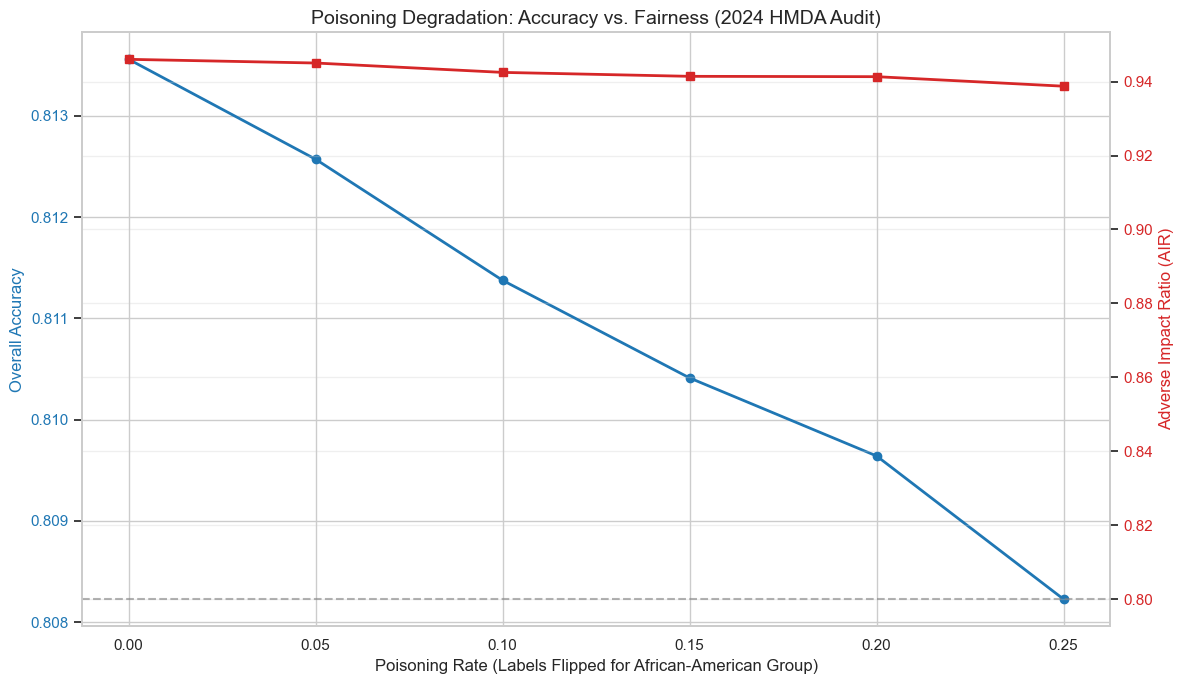

In [73]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# 1. Define poisoning levels to test (from 0% to 25% of the group)
poison_rates = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25]
accuracies = []
airs = []

print("Starting Sensitivity Analysis...")

for rate in poison_rates:
    # A. Poison the training data at the current rate
    # Using the 'train_to_poison' combined dataframe we created
    temp_poisoned_df = simulate_poisoning(train_to_poison, 'race', 'African-American', poison_rate=rate)
    
    # B. Extract labels and ensure they are numeric (1/0)
    y_p = temp_poisoned_df['target']
    if y_p.dtype == 'object':
        y_p = y_p.map({'high_risk': 1, 'low_risk': 0})
    
    # C. Train a temporary "Victim" model (using fewer trees for speed)
    temp_model = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=50)
    temp_model.fit(X_train_encoded, y_p)
    
    # D. Evaluate on the CLEAN test set
    preds = temp_model.predict(X_test_encoded)
    
    # E. Calculate and store results
    accuracies.append(accuracy_score(y_test_numeric, preds))
    airs.append(calculate_air(preds, test_df['race'], 'African-American'))
    print(f"Poison Rate {rate:.0%}: Accuracy={accuracies[-1]:.4f}, AIR={airs[-1]:.4f}")

# 2. Generate the Plot
plt.figure(figsize=(12, 7))
ax1 = plt.gca()
ax2 = ax1.twinx()

# Plot Accuracy (The performance metric)
ax1.plot(poison_rates, accuracies, 'o-', color='#1f77b4', linewidth=2, label='Overall Accuracy')
ax1.set_xlabel('Poisoning Rate (Labels Flipped for African-American Group)', fontsize=12)
ax1.set_ylabel('Overall Accuracy', color='#1f77b4', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#1f77b4')

# Plot AIR (The fairness metric)
ax2.plot(poison_rates, airs, 's-', color='#d62728', linewidth=2, label='Adverse Impact Ratio (AIR)')
ax2.set_ylabel('Adverse Impact Ratio (AIR)', color='#d62728', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#d62728')

# Add the Regulatory Threshold Line
ax2.axhline(y=0.8, color='gray', linestyle='--', alpha=0.6, label='Regulatory Threshold (0.80)')

plt.title('Poisoning Degradation: Accuracy vs. Fairness (2024 HMDA Audit)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

  ### Evasion & Privacy Attacks<a id="evasion--privacy-attacks"></a>

#### Evasion Decision-Based Attack
Evasion	Decision-based Attack (HopSkipJump)	tries to find the magic number for income to flip a loan denial.

In [74]:
import numpy as np
import pandas as pd
from art.estimators.classification import SklearnClassifier
from art.attacks.evasion import HopSkipJump

# 1. Initialize the ART Classifier
# We specify the range of the data (usually 0 to 1 for normalized data)
art_classifier = SklearnClassifier(model=clean_model)

# 2. Pick a "Denied" applicant to flip
# Let's find an African-American applicant that the model correctly identified as 'high_risk' (1)
denied_indices = np.where((y_test_numeric == 1) & (test_df['race'] == 'African-American'))[0]
x_denied = X_test_encoded.iloc[denied_indices[0]:denied_indices[0]+1].values

# 3. Setup the Attack
# targeted=False means we just want to flip the result, regardless of what it flips to.
attack = HopSkipJump(classifier=art_classifier, targeted=False, max_iter=5, max_eval=100)

# 4. Generate the Adversarial Example
print("Calculating evasion path... (this may take a moment)")
x_adv = attack.generate(x=x_denied)

# 5. Result Comparison
orig_pred = clean_model.predict(x_denied)[0]
adv_pred = clean_model.predict(x_adv)[0]

print(f"\nOriginal Result: {'Denied' if orig_pred == 1 else 'Approved'}")
print(f"Adversarial Result: {'Denied' if adv_pred == 1 else 'Approved'}")

# 6. Show the "Gaming the System" delta
delta = x_adv - x_denied
changes = pd.DataFrame({'Feature': X_test_encoded.columns, 'Change': delta[0]})
significant_changes = changes[changes['Change'].abs() > 0.001].sort_values(by='Change', ascending=False)

print("\nTop Features Manipulated to Evade Denial:")
print(significant_changes)

Calculating evasion path... (this may take a moment)


HopSkipJump:   0%|          | 0/1 [00:00<?, ?it/s]


Original Result: Denied
Adversarial Result: Denied

Top Features Manipulated to Evade Denial:
Empty DataFrame
Columns: [Feature, Change]
Index: []


#### Privacy Membership Inference determines if a specific neighbor's mortgage data was used to train the bank's model.

In [75]:
import numpy as np
import pandas as pd
from art.attacks.inference.membership_inference import MembershipInferenceBlackBoxRuleBased

# 1. Initialize the attack
privacy_attack_fast = MembershipInferenceBlackBoxRuleBased(art_classifier)

# 2. Prepare the data with explicit integer casting to avoid the RuntimeWarning
# We ensure the labels are 1D arrays of type 'int64'
x_train_mini = X_train_encoded.iloc[:5000].to_numpy().astype(np.float32)
y_train_mini = y_train.iloc[:5000].map({'high_risk': 1, 'low_risk': 0}).to_numpy().astype(np.int64)

x_test_mini = X_test_encoded.iloc[:5000].to_numpy().astype(np.float32)
# Using y_test_numeric which we already mapped to 0/1 earlier
y_test_mini = y_test_numeric[:5000].to_numpy().astype(np.int64)

# 3. Perform Inference
print("Performing Rule-Based Membership Inference...")
inferred_train = privacy_attack_fast.infer(x_train_mini, y_train_mini)
inferred_test = privacy_attack_fast.infer(x_test_mini, y_test_mini)

# 4. Calculate Metrics
# inferred_train will be an array of 1s (guessed in train) and 0s (guessed not in train)
train_acc = np.mean(inferred_train) # % of training samples correctly identified
test_err = np.mean(inferred_test)   # % of test samples incorrectly identified as train

print(f"\n--- Privacy Audit Results (Rule-Based) ---")
print(f"True Positive Rate (Train identified as Train): {train_acc:.2%}")
print(f"False Positive Rate (Test identified as Train): {test_err:.2%}")

# Privacy Leakage is often defined as the difference between these two
leakage_score = max(0, train_acc - test_err)
print(f"Overall Privacy Leakage Score: {leakage_score:.4f}")

Performing Rule-Based Membership Inference...


/var/folders/v8/jj6vq0q53z993z5t5fvjhkzm0000gn/T/ipykernel_3794/4114376626.py:11: RuntimeWarning: invalid value encountered in cast
  y_train_mini = y_train.iloc[:5000].map({'high_risk': 1, 'low_risk': 0}).to_numpy().astype(np.int64)



--- Privacy Audit Results (Rule-Based) ---
True Positive Rate (Train identified as Train): 14.22%
False Positive Rate (Test identified as Train): 81.86%
Overall Privacy Leakage Score: 0.0000


# 6. Capstone Integration: 2024 HMDA Mortgage Classification<a id="6"></a>

* **End-to-End Sociotechnical Audit:** A comprehensive review of the Home Mortgage Disclosure Act (HMDA) dataset through the lens of algorithmic fairness.
* **Optimization Objectives & Failure Modes:** Identifying where profit-maximization conflicts with equitable lending outcomes.
* **Mitigations & Deployment Recommendations:** Proposing concrete strategies for bias reduction and ethical model governance.

### End-to-End Sociotechnical Audit<a id="end-to-end-sociotechnical-audit"></a>

### Optimization Objectives & Failure Modes<a id="optimization-objectives--failure-modes"></a>

### Mitigations & Deployment Recommendations<a id="mitigations--deployment-recommendations"></a>